# <center> Lecture15 : Hierarchical Regression Models</center>  
 
## <center> Instructor: Dr. Hu Chuan-Peng </center> 

## Intro  

在上一节课中，我们学习了分层模型 (Hierarchical Models) 的基本概念，并探讨了分层模型的优点，然而这些模型本质是某个变量的估计，没有考虑实验条件的影响。  

但更多的情况下，我们是希望看到自变量与因变量的关系，这时需要结合回归分析方法。  

本节课，我们将层级模型与回归模型相结合，重点讲解分层线性模型 (Hierarchical Regression Models) 的应用。  

前几次课的练习均使用了“压力与自我控制关系”的例子，本节课将以该例子介绍分层线性模型的基本概念，在练习阶段时再回到随机点运动范式的情境。  

![Image Name](https://cdn.kesci.com/upload/image/rkz1ehen1l.png?imageView2/0/w/720/h/960)  




在上节课的练习中，仅考虑了自我控制分数在不同站点和不同个体间的变化。  

🤔 然而，压力对自我控制的影响是否在不同站点间存在差异？  

* 一种不太可能的情景是，不同站点间的自我控制分数没有差异，并且压力对自我控制的影响在不同站点间也相同，如图A。
* 一种可能是，自我控制分数在不同站点间存在差异，但是压力对自我控制的影响在不同站点不存在差异，如图B。  
* 另一种可能是，站点只调节压力对自我控制的影响，而各站点间自我控制分数相当，如图C。  
* 最后，站点可能既影响自我控制分数，又影响压力对自我控制的效应，如图D。  


![Image Name](https://cdn.kesci.com/upload/s5sh35okpe.png?imageView2/0/w/640/h/640)  

在本节课中，我们将介绍引入包含自变量时的层级模型，并通过不同的模型验证不同的假设：  
* H0(model 0)，图A，普通线性模型，仅考虑压力对自我控制的影响。  
* H1(model 1)，图B，变化截距模型，在模型0的基础上考虑自我控制在不同站点的变化。  
* H2(model 2)，图C，变化斜率模型，在模型0的基础上不同站点间的压力影响的变化。  
* H3(model 3)，图D，变化截距和斜率模型，结合模型1和模型2，同时考虑站点对自我控制以及压力影响的变化。  

![Image Name](https://cdn.kesci.com/upload/s5sh35okpe.png?imageView2/0/w/640/h/640)

## 回顾：贝叶斯回归模型的数学表达式  

在第八节课中讲解了贝叶斯的回归模型，还记得它的数学表达式吗？  

$$  
\begin{align*}  
\beta_0   &\sim N\left(m_0, s_0^2 \right)  \\  
\beta_1   &\sim N\left(m_1, s_1^2 \right)  \\  
\sigma    &\sim \text{Exp}(\lambda)        \\  
&\Downarrow \\  
\mu_i &= \beta_0 + \beta_1 X_i             \\  
&\Downarrow \\  
Y_i | \beta_0, \beta_1, \sigma &\sim N\left(\mu_i, \sigma^2\right). \\  
\end{align*}  
$$  

* 回归模型需满足如下假设：  

    1. 独立观测假设:每个观测值$Y_i$是相互独立的。  

    2. 线性关系假设: 预测值$\mu_i$和自变量$X_i$之间可以用线性关系来描述，即：$\mu_i = \beta_0 + \beta_1 X_i$  

    3. 方差同质性假设： 在任意自变量的取值下，观测值$Y_i$都会以$\mu_i$为中心，同样的标准差$\sigma$呈正态分布变化（$\sigma$ is consistent）  





贝叶斯回归模型的优势：

允许将实验假设以回归参数的形式进行表达，并通过后验分布来量化这些假设的合理性。

$$  
RT_{sec} \sim \mathcal{N}(\beta_0 + \beta_1 \cdot Label, \sigma^2)  
$$  

* 通过后验分布检验 $\beta_1$ 是否显著，例如计算 $\beta_1 > 0$ 或 $\beta_1 < 0$ 的概率，或计算最高密度区间（HDI）。如果 95% HDI 不包含 0，可以认为自我条件和他人条件在反应时间上的差异是显著的。
* 在贝叶斯框架下，我们不仅可以观察参数的点估计（如 $\beta_1$ 的均值），还可以通过后验分布和 HDI 提供更加直观的置信水平解释。

![Image Name](https://cdn.kesci.com/upload/smkijcu8co.png?imageView2/0/w/650)  

*(改编自：https: // saylordotorg.github.io/text_introductory-statistics/s14-03-modelling-linear-relationships.html)*  

<br><br>  

<div style="padding-bottom: 20px;"></div>

## Model0: Complete pooling  


以 “压力与自我控制关系” 为例， 如果忽略数据的层级结构，认为所有数据都来自一个更大的总体，只需要用一个回归方程来描述自变量与因变量的关系。  

$$  
\begin{array}{lcrl}  
\text{data:} & \hspace{.05in} &   Y_i | \beta_0, \beta_1, \sigma & \stackrel{ind}{\sim} N\left(\mu_i, \sigma^2\right) \;\; \text{ with } \;\; \mu_i = \beta_0 + \beta_1X_i \\  

\text{priors:} & & \beta_{0}  & \sim N\left(0, 50^2 \right)  \\  
                    & & \beta_1  & \sim N\left(0, 5^2 \right) \\  
                    & & \sigma   & \sim \text{Exp}(1)  \\  
\end{array}  
$$ 

* 其中， $Y_i$ 是第 $i$ 个被试的自我控制分数，
* $X_i$ 是第 $i$ 个被试的压力得分，
* $\beta_0$ 和 $\beta_1$ 是回归系数，$\sigma$ 是残差的标准差。
* $\beta_1$ 代表了压力与自我控制之间的关系。  

![Image Name](https://cdn.kesci.com/upload/s3y4rmsym1.png?imageView2/0/w/960/h/960)  

In [41]:
# 安装和加载包
options(repos = c(CRAN = "https://mirrors.tuna.tsinghua.edu.cn/CRAN/"))
if (!requireNamespace('pacman', quietly = TRUE)) {
    install.packages('pacman')
}
pacman::p_load("tidyverse","ggplot2", "dplyr","gridExtra","patchwork","papaja", "bayesplot",
               "rstan","bridgesampling", 'logspline', "easystats", "brms", "RColorBrewer","loo") 
options(warn = -1)  # 抑制警告

In [2]:
# 导入数据
df_raw <- tryCatch({
  read.csv('/home/mw/input/bayes3797/Data_Sum_HPP_Multi_Site_Share.csv')
}, error = function(e) {
  read.csv('data/Data_Sum_HPP_Multi_Site_Share.csv')
})

# 选取5个站点
first5_site <- c('Southampton','Portugal','Kassel','Tsinghua','UCSB') 
df_first5 <- df_raw %>%
  dplyr::filter(Site %in% first5_site)

# 为site生成索引 + 生成obs_id列
df_first5 <- df_first5 %>%
  dplyr::mutate(
    site_idx = as.integer(factor(Site, levels = first5_site)) - 1, 
    obs_id = dplyr::row_number() - 1  # 保留为列
  ) %>%
  dplyr::mutate(
    Site = factor(Site, levels = first5_site)  # 确保Site按指定顺序排列
  )

# 查看前5行数据
head(df_first5, 5)

,age,anxiety,anxiety_r,artgluctot,attachhome,attachphone,AvgHumidity,avgtemp,avoidance,avoidance_r,⋯,sex,Site,smoke,socialdiversity,socialembedded,socTherm,soliTherm,stress,site_idx,obs_id
,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,⋯,<int>,<fct>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<dbl>,<dbl>
1,1955,3.500000,0.32378853,0,3.222222,3.666667,89,36.300,3.777778,1.0614738,⋯,1,Kassel,2,6,3,3.0,3.125,30,2,0
2,1959,1.500000,-1.38045564,0,4.444444,2.111111,NA,36.600,2.722222,-0.1248793,⋯,2,Kassel,2,7,4,2.4,3.125,30,2,1
3,1965,1.333333,-1.52247598,0,3.666667,2.000000,NA,35.450,2.611111,-0.2497585,⋯,1,Kassel,2,5,2,3.8,2.375,31,2,2
4,1966,3.222222,0.08708795,0,4.333333,1.000000,NA,36.630,3.166667,0.3746378,⋯,2,Kassel,2,9,2,3.6,2.875,47,2,3
5,1969,3.444444,0.27644841,0,3.555556,1.444444,69,36.465,3.222222,0.4370774,⋯,2,Kassel,2,11,3,2.2,2.750,50,2,4


`geom_smooth()` using formula = 'y ~ x'


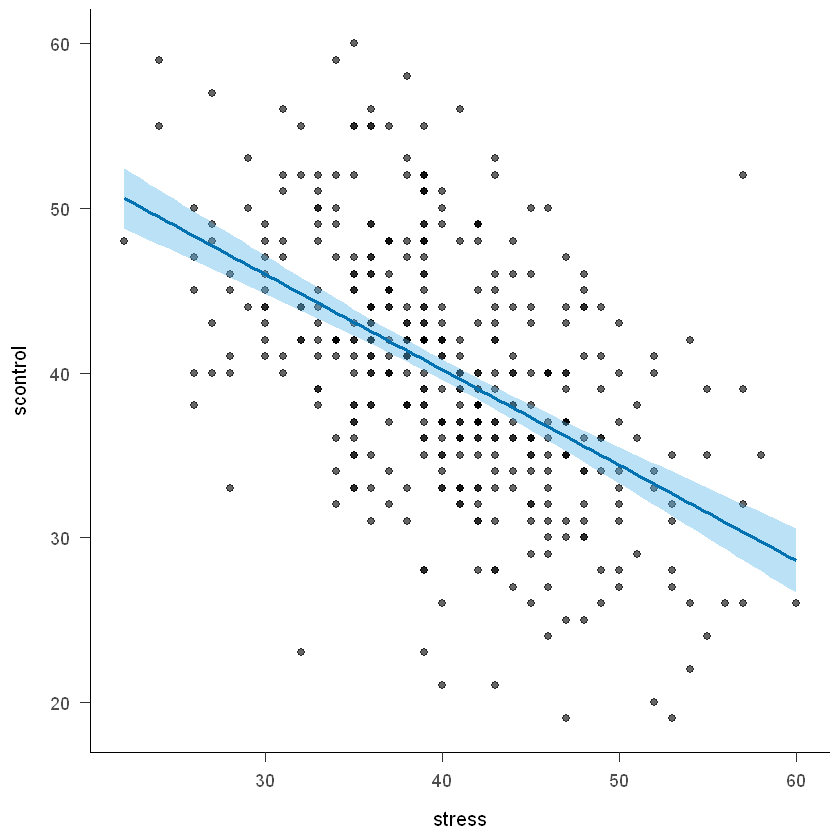

In [3]:
ggplot2::ggplot(data = df_first5, aes(x = stress, y = scontrol)) +
  # 散点层
  ggplot2::geom_point(alpha = 0.6, size = 2) +
  # 线性回归拟合层
  ggplot2::geom_smooth(method = "lm", se = TRUE, color = "#0072B2", fill = "#56B4E9") +
  papaja::theme_apa()

### 模型定义与采样

$$  
\begin{array}{lcrl}  
\text{data:} & \hspace{.05in} &   Y_i | \beta_0, \beta_1, \sigma & \stackrel{ind}{\sim} N\left(\mu_i, \sigma^2\right) \;\; \text{ with } \;\; \mu_i = \beta_0 + \beta_1X_i \\  

\text{priors:} & & \beta_{0}  & \sim N\left(40, 20^2 \right)  \\  
                    & & \beta_1  & \sim N\left(0, 5^2 \right) \\  
                    & & \sigma   & \sim \text{Exp}(1)  \\  
\end{array}  
$$ 

In [44]:
# 构建完全池化模型
complete_pooled_model <- brms::brm(
  scontrol ~ 1 + stress,
  data = df_first5,
  family = gaussian(),
  iter = 2000,
  warmup = 1000,
  chains = 4,
  cores = 4,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling



### 后验参数估计：  

结果显示：  

$\mu_i = \beta_0 + \beta_1X_i$  
- $\beta_0 = 63.38$  
- $\beta_1 = -0.58$

$\beta_1 = -0.58$ 表明，在给定站点的情况下，自我控制水平与压力水平之间存在负相关关系。并且，压力分数每增加1分，自我控制水平平均下降0.58分。

In [45]:
summary(complete_pooled_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: scontrol ~ 1 + stress 
   Data: df_first5 (Number of observations: 415) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    63.38      1.97    59.63    67.24 1.00     4356     2923
stress       -0.58      0.05    -0.67    -0.49 1.00     4414     3092

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     6.52      0.23     6.08     6.98 1.00     4148     2556

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat is the potential
scale reduction factor on split chains (at convergence, Rhat = 1).

### 后验预测回归线  

* 完全池化模型假设，所有站点中自我控制分数一致，并且压力的影响也一致。  
* 下图展示了不同站点下后验预测的结果，可以看到他们的回归线是一致的。

In [10]:
# 定义函数，用来按站点绘制后验预测回归线
# 获取站点列表
get_group_index <- function(data) {
  # 直接返回排序后的站点唯一值
  groups <- unique(data$Site)
  return(groups)
}

# 按站点绘制后验预测回归线
plot_regression <- function(data, model, groups) {
  # 提取后验预测的期望值（mu），返回每个观测的后验样本
  posterior_mu <- brms::posterior_epred(model, summary = FALSE)
  
  # 将后验预测值与原始数据合并（按行匹配）
  mu_df <- as.data.frame(posterior_mu) %>%
    tidyr::pivot_longer(cols = everything(), names_to = "row_idx", values_to = "mu") %>%
    dplyr::mutate(row_idx = as.integer(gsub("V", "", row_idx))) %>%
    dplyr::group_by(row_idx) %>%
    dplyr::summarise(
      mu_mean = mean(mu),
      mu_hdi_lower = bayestestR::hdi(mu, ci = 0.95)$CI_low,
      mu_hdi_upper = bayestestR::hdi(mu, ci = 0.95)$CI_high
    ) %>%
    dplyr::bind_cols(data %>% dplyr::mutate(row_idx = dplyr::row_number()))
  
  # 定义变量名
  x_var <- "stress"
  y_var <- "scontrol"
  site_var <- "Site"
  n_groups <- length(groups)
  
  site_colors <- RColorBrewer::brewer.pal(n_groups, "Set1")

  plot_list <- list()
  
  # 按站点循环绘图
  for (i in seq_along(groups)) {
    group <- groups[i]
    # 筛选当前站点的数据
    group_data <- mu_df %>%
      dplyr::filter(!!sym(site_var) == group)
    
    # 绘制当前站点的图形
    p <- ggplot2::ggplot(group_data, aes(x = !!sym(x_var), y = !!sym(y_var))) +
      # 原始数据散点
      ggplot2::geom_point(color = site_colors[i], alpha = 0.5) +
      # 后验均值回归线
      ggplot2::geom_line(
        aes(y = mu_mean), color = site_colors[i], alpha = 0.5) +
      # 95%HDI填充带
      ggplot2::geom_ribbon(aes(ymin = mu_hdi_lower, ymax = mu_hdi_upper),
        fill = site_colors[i], alpha = 0.25) +
      # 站点名称作为标题
      ggplot2::ggtitle(label = group) +
      # 统一坐标轴范围
      ggplot2::xlim(range(mu_df[[x_var]])) +
      ggplot2::ylim(range(mu_df[[y_var]])) +
      papaja::theme_apa() +
      ggplot2::theme(
        plot.title = ggplot2::element_text(hjust = 0.5),
        axis.title.x = ggplot2::element_blank(),
        axis.title.y = ggplot2::element_blank()
      )
    
    plot_list[[i]] <- p
  }
  
  combined_plot <- patchwork::wrap_plots(plot_list, nrow = 1) +
    patchwork::plot_annotation(
      title = "Posterior regression models",
      theme = theme(plot.title = element_text(hjust = 0.5, size = 15))
    )
  
  # 打印图形并添加全局标签
  print(combined_plot)
  grid::grid.text("Stress", x = 0.5, y = 0.02, gp = grid::gpar(fontsize = 12))
  grid::grid.text("Self control", x = 0.02, y = 0.5, rot = 90, gp = grid::gpar(fontsize = 12))
}

New names:
• `row_idx` -> `row_idx...1`
• `row_idx` -> `row_idx...44`


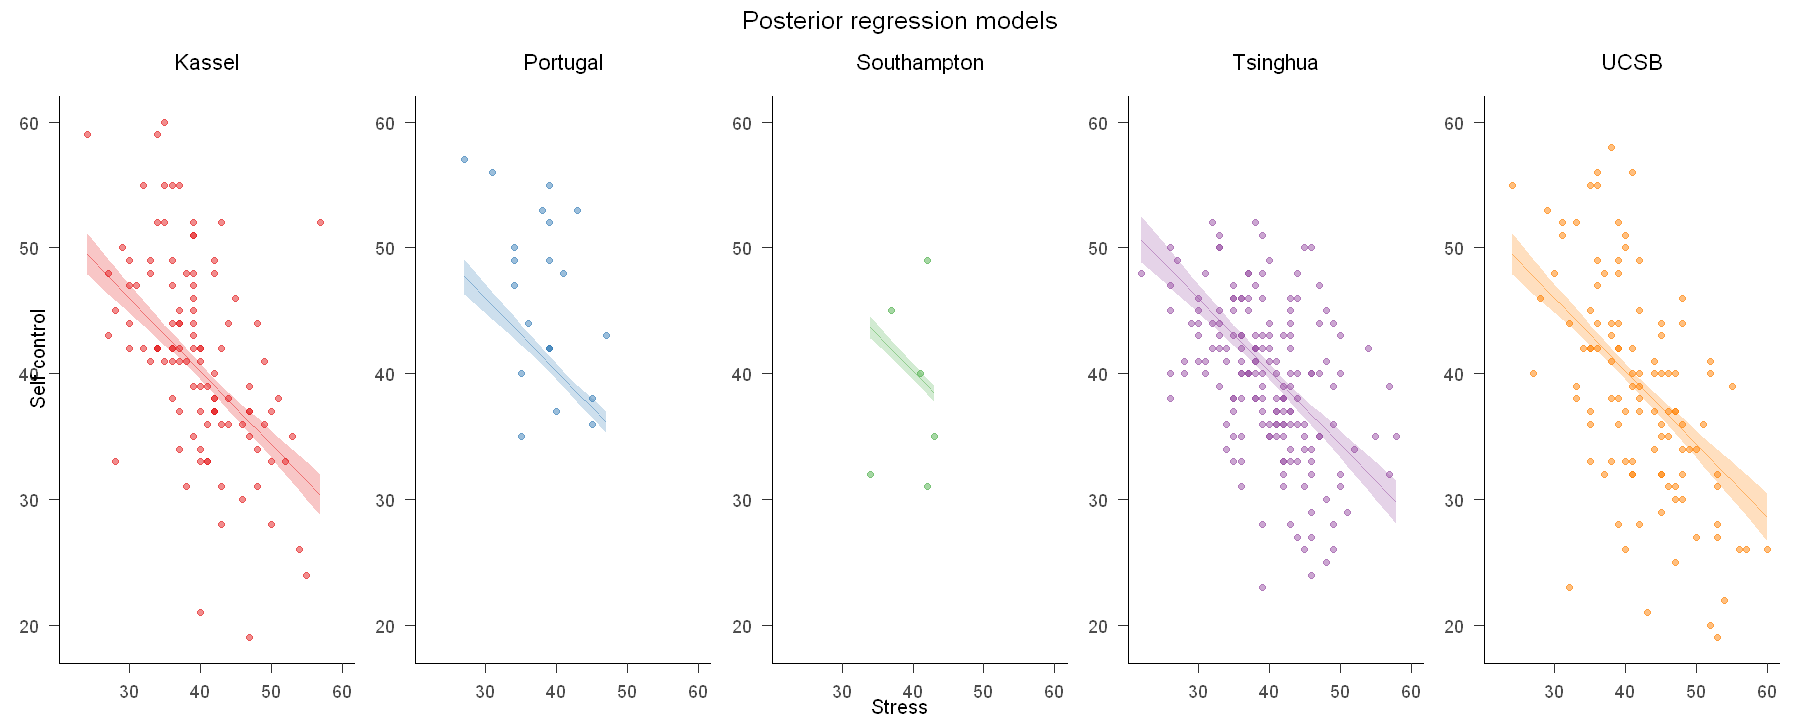

In [61]:
options(repr.plot.width = 15, repr.plot.height = 6)

# 获取站点列表
groups <- get_group_index(df_first5)

# 进行可视化
plot_regression(data = df_first5, model = complete_pooled_model, groups = groups)

## Partial pooling & hierarchical model  

完全池化 (complete pooling) 模型假设所有站点下回归模型的截距 ($\beta_0$) 和斜率 ($\beta_1$) 都相同。没有考虑到不同站点下回归模型的截距 ($\beta_0$) 和斜率 ($\beta_1$) 都可能发生变化的情况。

而在上节课的学习中，我们知道部分池化 (partial pooling) 模型可以解决这一问题。 

🤔 问题在于：如何将部分池化方法应用于回归模型？

![Image Name](https://cdn.kesci.com/upload/s5eeyrh0s5.png?imageView2/0/w/700)  

* $j$来表示站点，$j \in \{1,2, \ldots, 5\}$  
* $i$来表示站点内部的每一个数据$i \in \{1,2,\ldots,n_j\}$  
* 每一个被试的数据可以被表示为$Y_{ij}$，表示站点$j$内的第$i$个被试的自我控制分数观测值  

$$  
Y := \left((Y_{11}, Y_{21}, \ldots, Y_{n_1,1}), (Y_{12}, Y_{22}, \ldots, Y_{n_2,2}), \ldots, (Y_{1,5}, Y_{2,5}, \ldots, Y_{n_{5},5})\right)  .  
$$ 

本节课将重点讲解3种不同情况下的部分池化模型，以考虑回归模型的截距 ($\beta_0$) 和斜率 ($\beta_1$) 如何随着站点进行变化。

Outline:  
1. 考虑截距 ($\beta_0$)随站点变化的模型 (model1，变化截距模型)  
2. 考虑斜率 ($\beta_1$) 随站点变化的模型 (model2，变化斜率模型)  
3. 同时考虑截距 ($\beta_0$)和斜率 ($\beta_1$) 随站点的变化 (model3，变化截距和斜率模型)  
4. 最后，考虑分层回归模型中如何纳入组层面预测因子（group-level predictors）的影响。
  - 例如，相对于个体压力对于自我控制的影响，不同站点的气候是否对自我控制有影响。
  - 个体压力是个体层面的预测因子，气候是*组层面的预测因子*。

##  Model1: Hierarchical model with varying intercepts  

相较于没有自变量的分层模型，构建包含自变量的分层模型的关键在于区分 **参数($\beta$)** 和 **分层(layer)** 的关系。  


**prior**

$$  
\begin{array}{rll} 
\beta_{0}  & \sim N(40, 20^2) & \\  
\beta_1  & \sim N(0, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_0 & \sim \text{Exp}(1)    & \\  
\end{array}  
$$  

**likelihood**

$$  
\begin{array}{rll}
\beta_{0j} | \beta_0, \sigma_0  & \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2)  & \text{Layer 2: 全局水平（表示截距在站点间的变化）} \\  
Y_{ij} | \beta_{0j}, \beta_1, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_1 X_{ij}& \text{Layer 1: 被试水平（表示每个站点内的线性模型）} \\  
\end{array}  
$$

### Layer 1: Variability within Site  

**1. 自我控制与压力之间的关系在被试内有什么不同**  

$$  
Y_{ij} | \beta_{j}, \beta_1, \sigma_y \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ where } \; \mu_{ij} = \beta_{0j} + \beta_1 X_{ij}  .  
$$  

* 使用$i$表示每个站点内的第$i$个被试，$i \in (1,2,3...n)$  
* 对于每一个被试来说，其自我控制分数服从以$\mu_{ij}$为均值，$\sigma_y$为标准差的正态分布  

* 而$\mu_{ij}$由参数$\beta_{0j}$，$\beta_1$决定  

    * 其中，$\beta_{0j}$在组与组之间不同(group-specific)  

    * $\beta_1$和$\sigma_y$则是相同的(global)

### Layer 2: Variability between Site  
**2. 自我控制与压力之间的线性关系在站点间有什么不同**  

* 自我控制与压力之间的线性关系由截距和斜率两方面构成  

* 我们认为在不同的站点之间，其截距是变化的  

* 假设截距的基线(baseline)为$\beta_{0}$，不同站点间的组间差异为$\sigma_{0}$，则每个站点的截距可以表示为：  

$$  
\beta_{0j} | \beta_0, \sigma_0 \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2)  .  
$$

###  Global priors  

**3. 最后，全局参数也需要设置先验，包括 $\beta_{0}, \beta_1,  \sigma_0$**  

$$  
\begin{array}{rll}  
\beta_{0}  & \sim N(m_0, s_0^2)  \\  
\beta_1  & \sim N(m_1, s_1^2) & \\  
\sigma_y & \sim \text{Exp}(l_y)    & \\  
\sigma_0 & \sim \text{Exp}(l_0)    & \\  
\end{array}  

$$

**总结模型定义：**  

**prior**

$$  
\begin{array}{rll} 
\beta_{0}  & \sim N(40, 20^2) & \\  
\beta_1  & \sim N(0, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_0 & \sim \text{Exp}(1)    & \\  
\end{array}  
$$  

**likelihood**

$$  
\begin{array}{rll}
\beta_{0j} | \beta_0, \sigma_0  & \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2)  & \text{Layer 2: 全局水平（表示截距在站点间的变化）} \\  
Y_{ij} | \beta_{0j}, \beta_1, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_1 X_{ij}& \text{Layer 1: 被试水平（表示每个站点内的线性模型）} \\  
\end{array}  
$$

### 模型定义与采样  

* 首先，我们设定总体的参数 $\beta_0$, $\beta_1$。  
	* 由于 $\beta_{0j}$ 在不同站点间不同，因此我们 设定总体参数 $\sigma_0$ 并假设每个站点 $\beta_{0j} \sim N(\beta_0, \sigma_0)$  
	 
	*  在另一种定义方式下，我们将$\beta_{0j}$ 视为 $\beta_0$与$b_{0j}$的组合  
	* 之后，我们通过线性公式生成 $\mu_j = \beta_{0j} + \beta_1 * x$  
	* 最后，个体层面的数据 y 服从 $N(\mu_j, \sigma_y)$，其中 $\sigma_y$ 为组内变异。  


In [62]:
prior_list <- c(
  brms::prior(normal(40, 20), class = Intercept),
  brms::prior(normal(0, 5), class = b, coef = stress),
  brms::prior(exponential(1), class = sd, group = Site, coef = Intercept),
  brms::prior(exponential(1), class = sigma)
)

var_inter_model <- brms::brm(
    scontrol ~ stress + (1 | Site), # 仅随机截距
    data = df_first5,
    family = gaussian(),
    prior = prior_list,
    iter = 5000,          # 模型变复杂之后加大采样量
    warmup = 1000,
    chains = 4,
    seed = 84735,
    control = list(adapt_delta = 0.95)
  )

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000124 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 1.24 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 5000 [  0%]  (Warmup)
Chain 1: Iteration:  500 / 5000 [ 10%]  (Warmup)
Chain 1: Iteration: 1000 / 5000 [ 20%]  (Warmup)
Chain 1: Iteration: 1001 / 5000 [ 20%]  (Sampling)
Chain 1: Iteration: 1500 / 5000 [ 30%]  (Sampling)
Chain 1: Iteration: 2000 / 5000 [ 40%]  (Sampling)
Chain 1: Iteration: 2500 / 5000 [ 50%]  (Sampling)
Chain 1: Iteration: 3000 / 5000 [ 60%]  (Sampling)
Chain 1: Iteration: 3500 / 5000 [ 70%]  (Sampling)
Chain 1: Iteration: 4000 / 5000 [ 80%]  (Sampling)
Chain 1: Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain 1: Iteration: 5000 / 5000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.976 seconds (Warm-up)
Chain 1:                3.435 seconds (Sampling)
Chain 1:             

### 先验预测检查

In [63]:
prior_only_model <- brms::brm(
  formula = scontrol ~ stress + (1 | Site),
  data = df_first5,
  family = gaussian(),
  prior = prior_list,
  sample_prior = "only",  # 仅从先验采样，不拟合数据
  iter = 1000,  # 仅先验采样，可减少采样数量
  chains = 4,
  seed = 84735
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 3.4e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.34 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:   1 / 1000 [  0%]  (Warmup)
Chain 1: Iteration: 100 / 1000 [ 10%]  (Warmup)
Chain 1: Iteration: 200 / 1000 [ 20%]  (Warmup)
Chain 1: Iteration: 300 / 1000 [ 30%]  (Warmup)
Chain 1: Iteration: 400 / 1000 [ 40%]  (Warmup)
Chain 1: Iteration: 500 / 1000 [ 50%]  (Warmup)
Chain 1: Iteration: 501 / 1000 [ 50%]  (Sampling)
Chain 1: Iteration: 600 / 1000 [ 60%]  (Sampling)
Chain 1: Iteration: 700 / 1000 [ 70%]  (Sampling)
Chain 1: Iteration: 800 / 1000 [ 80%]  (Sampling)
Chain 1: Iteration: 900 / 1000 [ 90%]  (Sampling)
Chain 1: Iteration: 1000 / 1000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.035 seconds (Warm-up)
Chain 1:                0.022 seconds (Sampling)
Chain 1:                0.057 seconds (

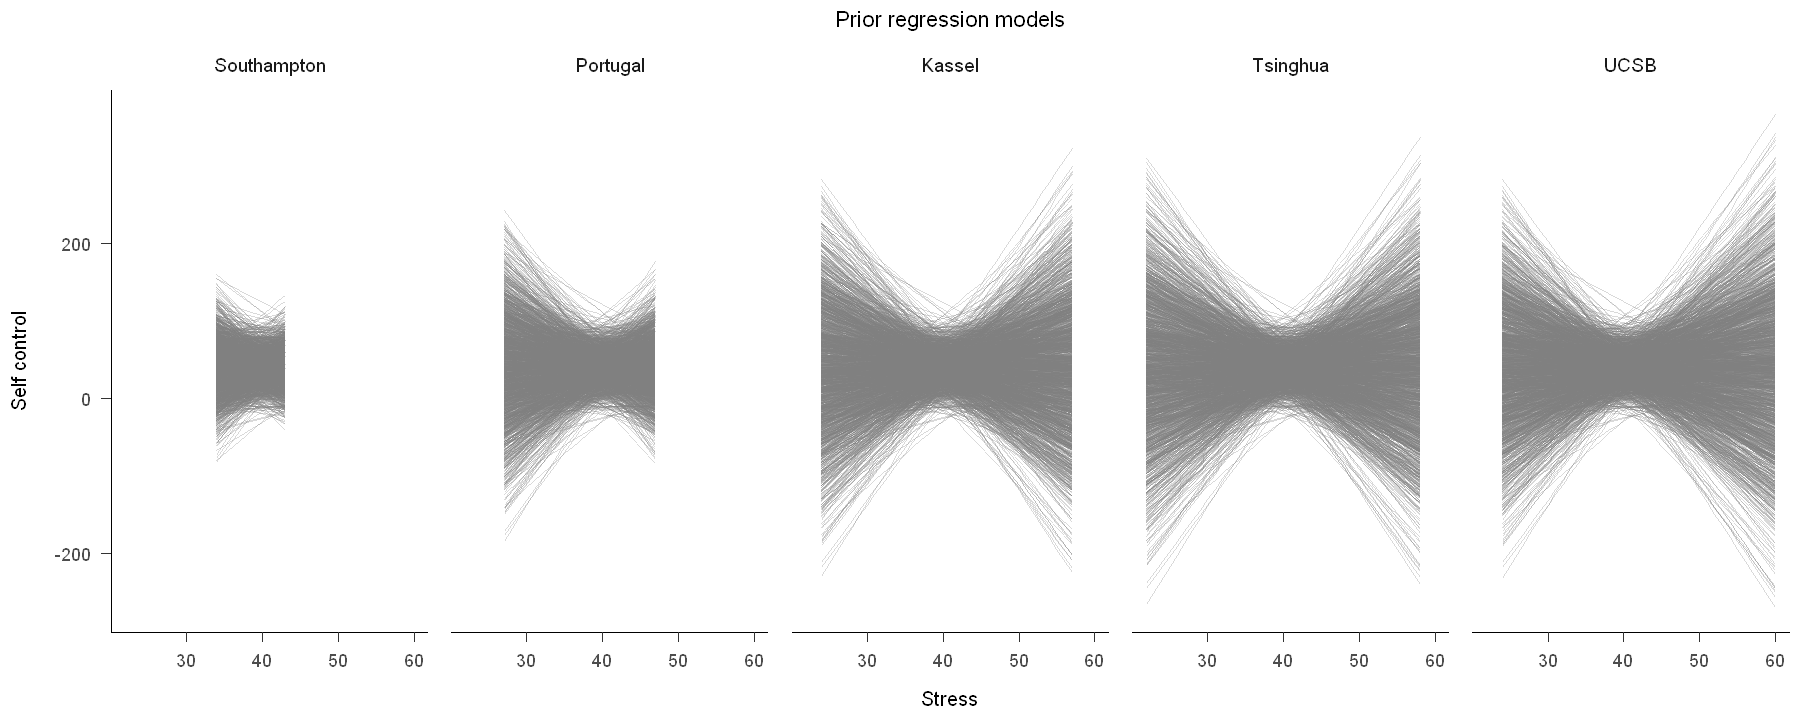

In [64]:
# 定义函数：绘制分站点的先验预测回归线集合
plot_prior <- function(prior_only_model, data) {
  # 提取先验预测的mu值
  prior_mu_samples <- brms::posterior_linpred(
    prior_only_model,
    newdata = data,
    draws = 200,
    return_matrix = TRUE  # 强制返回矩阵，方便处理
  )
  
  # 给矩阵添加行名（先验样本ID）和列名（观测值ID）
  rownames(prior_mu_samples) <- paste0("sample_", 1:nrow(prior_mu_samples))
  colnames(prior_mu_samples) <- paste0("obs_", 1:ncol(prior_mu_samples))
  
  prior_mu_df <- as.data.frame(prior_mu_samples) %>%
    # 添加先验样本ID列
    tibble::rownames_to_column("sample_id") %>%
    # 转长格式
    tidyr::pivot_longer(
      cols = -sample_id,
      names_to = "obs_id",
      values_to = "prior_mu"
    ) %>%
    # 提取观测值的数字索引
    dplyr::mutate(
      obs_idx = as.integer(gsub("obs_", "", obs_id)),
      sample_id = factor(sample_id)  # 转为因子，方便分组
    ) %>%
    # 匹配原始数据的Site、stress
    dplyr::left_join(
      data %>% dplyr::mutate(obs_idx = dplyr::row_number()),
      by = "obs_idx"
    ) %>%
    # 按Site和sample_id分组，对stress排序
    dplyr::group_by(Site, sample_id) %>%
    dplyr::arrange(stress, .by_group = TRUE) %>%
    dplyr::ungroup()
  
  # 分站点绘图
  p <- ggplot2::ggplot(prior_mu_df, aes(x = stress, y = prior_mu, group = sample_id)) +
    # 绘制多条先验预测回归线
    ggplot2::geom_line(color = "gray50", alpha = 0.3) +

    ggplot2::facet_wrap(~ Site, nrow = 1, scales = "fixed") +
    ggplot2::labs(x = "Stress", y = "Self control", title = "Prior regression models"
    ) +
    papaja::theme_apa() 
    
  print(p)
  return(invisible(p))
}

options(repr.plot.width = 15, repr.plot.height = 6)
# 调用绘图函数
plot_prior(
  prior_only_model = prior_only_model,
  data = df_first5
)

###  MCMC采样&后验参数估计  

* 可以看到5条回归线的斜率都是一致的 $\beta_1 = -0.56$  
* 总体层面的解决 $\beta_0 = 63.15$  
* 但截距$\beta_{0j}$[xx]有所不同:  
    * $\beta_{0}$[Kassel] = 63.52  
    * $\beta_{0}$[Portugal] = 65.34
    * $\beta_{0}$[Southampton] = 62.52 
    * $\beta_{0}$[Tsinghua] = 62.04 
    * $\beta_{0}$[UCSB] = 62.32

In [68]:
summary(var_inter_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: scontrol ~ stress + (1 | Site) 
   Data: df_first5 (Number of observations: 415) 
  Draws: 4 chains, each with iter = 5000; warmup = 1000; thin = 1;
         total post-warmup draws = 16000

Multilevel Hyperparameters:
~Site (Number of levels: 5) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     1.58      0.84     0.25     3.52 1.00     3453     2551

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    63.41      2.11    59.27    67.55 1.00    10913    10336
stress       -0.57      0.05    -0.66    -0.48 1.00    13488    11004

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     6.38      0.22     5.96     6.83 1.00    13137    10634

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and Rhat i

In [ ]:
site_coef <- as.data.frame(stats::coef(var_inter_model))

#整理数据
coef_df <- as.data.frame(summary(var_inter_model)$fixed)

plot_hdi <- site_coef %>%
  dplyr::select(1:5) %>%
  dplyr::rename(Intercept = 1, 
         Intercept_error = 2, 
         Intercept_Q2.5 = 3, 
         Intercept_Q97.5 = 4) %>%
  dplyr::bind_rows(
    data.frame(Intercept = coef_df$Estimate, Intercept_error = coef_df$Est.Error, 
               Intercept_Q2.5 = coef_df$`l-95% CI`, Intercept_Q97.5 = coef_df$`u-95% CI`) %>%
      slice(1)
  )
rownames(plot_hdi)[nrow(plot_hdi)] <- "beta0"

plot_hdi <- plot_hdi %>%
  tibble::rownames_to_column("site")
plot_hdi

site,Intercept,Intercept_error,Intercept_Q2.5,Intercept_Q97.5,Site.Estimate.stress
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Southampton,62.85489,2.445484,57.96918,67.54978,-0.5689977
Portugal,65.57535,2.322007,61.09442,70.16639,-0.5689977
Kassel,63.77675,1.970258,59.90865,67.59037,-0.5689977
Tsinghua,62.32555,1.965455,58.46683,66.21920,-0.5689977
UCSB,62.61420,2.065713,58.56696,66.67232,-0.5689977
beta0,63.40861,2.105017,59.27494,67.54563,NA


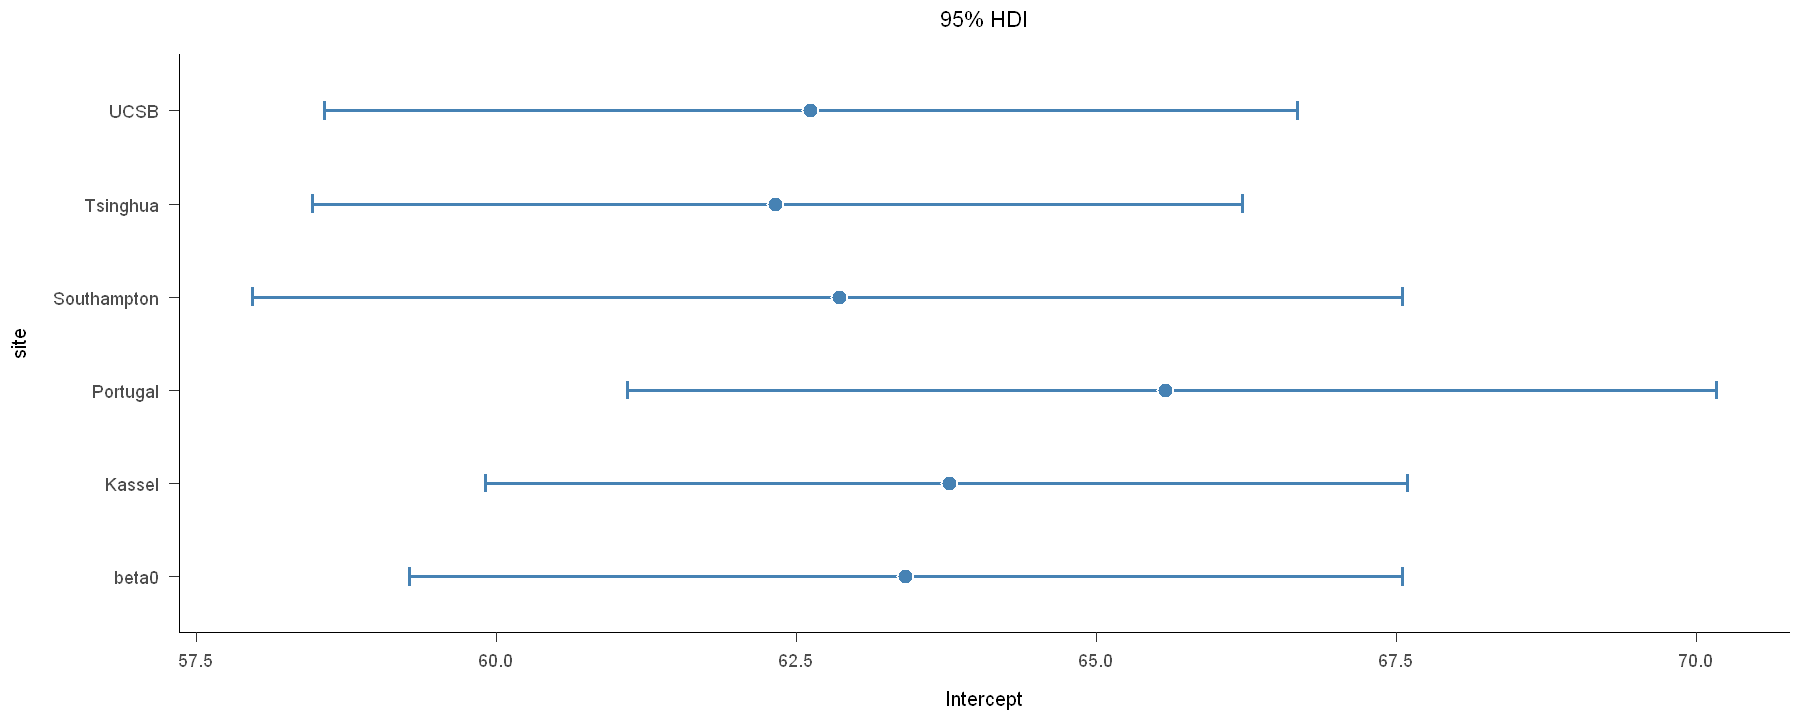

In [70]:
#可视化
ggplot2::ggplot(plot_hdi, aes(x = Intercept, y = site)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = plot_hdi$Intercept_Q2.5, xmax = plot_hdi$Intercept_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

### 后验预测回归线  

* 5条回归线的截距不同，斜率相同

New names:
• `row_idx` -> `row_idx...1`
• `row_idx` -> `row_idx...44`


text[GRID.text.3511] 

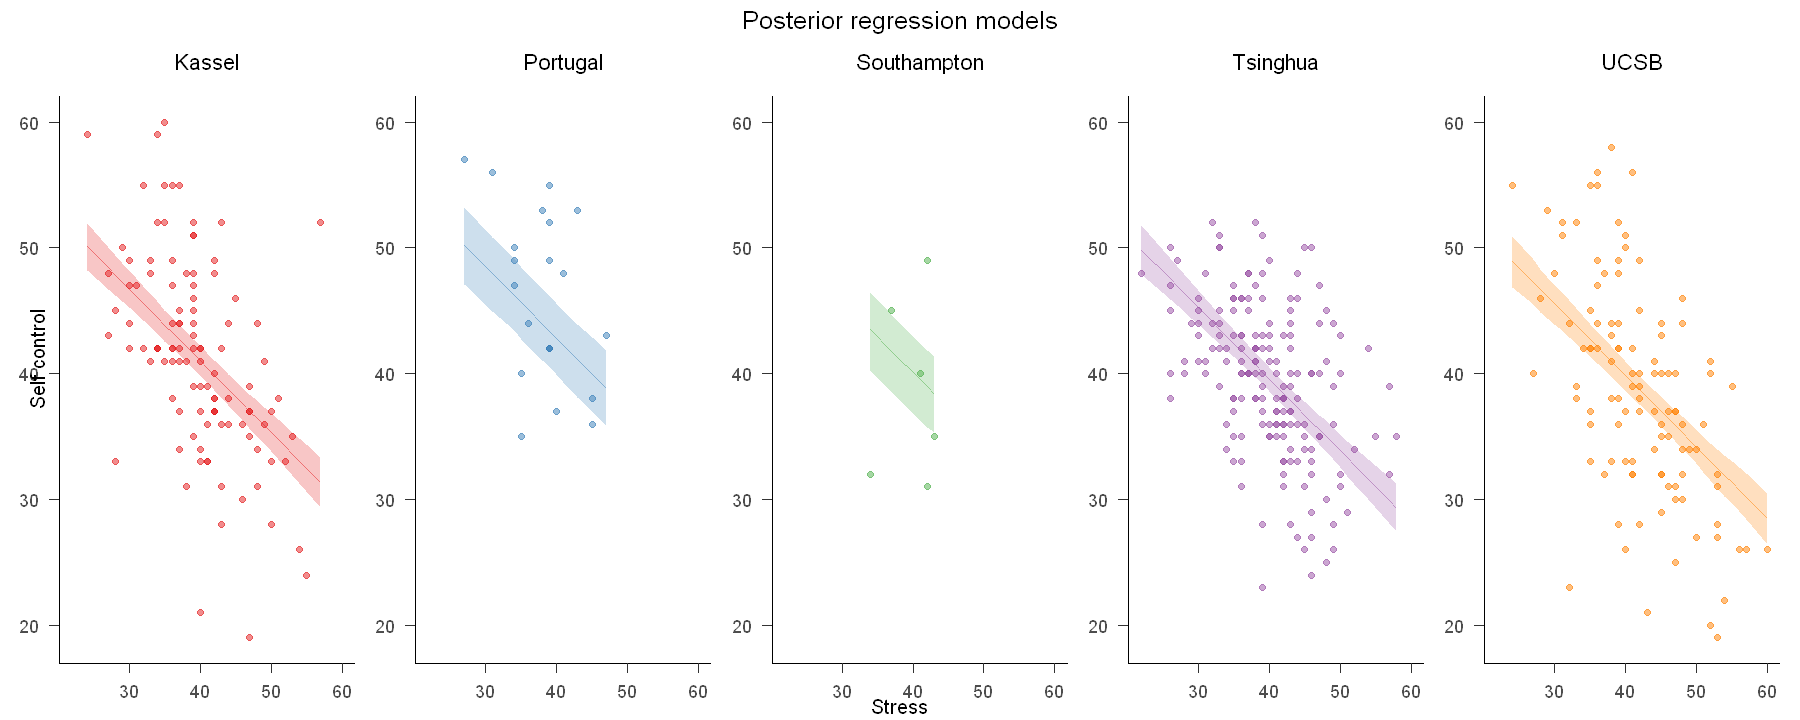

In [75]:
# 获取站点列表
groups <- get_group_index(df_first5)

# 进行可视化
p1 <- plot_regression(data = df_first5, model = var_inter_model, groups = groups)
p1

### 组间方差与组内方差  

* 在这个模型定义中，组间方差来自`beta_0_offset`，组内方差来自`sigma_y`  
* 结果发现：组间变异 (0.058) 小于组内变异 (0.942)，表明组内相关性低。

In [77]:
# 提取随机效应的变异信息
model_var <- brms::VarCorr(var_inter_model)

# 提取组间变异
sd_intercept <- model_var$Site$sd[1]  
between_var_intercept <- as.numeric(sd_intercept)^2

# 提取组内变异（从后验样本计算）
sigma_samples <- brms::posterior_samples(var_inter_model, pars = "sigma")
residual_sd <- mean(sigma_samples$sigma)
within_var <- residual_sd^2

# 计算变异解释比例
total_var_intercept <- between_var_intercept + within_var
prop_intercept_between <- (between_var_intercept / total_var_intercept) * 100  # 组间解释百分比
prop_intercept_within <- (within_var / total_var_intercept) * 100            # 组内解释百分比

cat("组间方差：", round(between_var_intercept, 4), "\n")
cat("组内方差：", round(within_var, 4), "\n")
cat("被组间方差所解释的部分：", round(prop_intercept_between, 2), "%\n")
cat("被组内方差所解释的部分：", round(prop_intercept_within, 2), "%\n\n")

组间方差： 2.5084 
组内方差： 40.7428 
被组间方差所解释的部分： 5.8 %
被组内方差所解释的部分： 94.2 %



## Model2: Hierarchical model with varying slopes  

* 上一个模型考虑了回归截距随站点的变化，在模型2中，可假设不同站点间的回归截距保持不变，但回归斜率随站点变化。  

$$  
\beta_{1j} | \beta_1, \sigma_1 \sim N(\beta_1, \sigma_1^2)  
$$  

类似于模型1，**模型2的定义形式为：**  

**prior**

$$  
\begin{array}{rll} 
\beta_{0}  & \sim N(40, 20^2) & \\  
\beta_1  & \sim N(0, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_1 & \sim \text{Exp}(1)    & \\  
\end{array}  
$$  

**likelihood**

$$  
\begin{array}{rll}
\beta_{1j} | \beta_1, \sigma_1  & \stackrel{ind}{\sim} N(\beta_1, \sigma_1^2)  & \text{Layer 2: 全局水平（表示斜率在站点间的变化）} \\  
Y_{ij} | \beta_{0}, \beta_{1j}, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0} + \beta_{1j} X_{ij}& \text{Layer 1: 被试水平（表示每个站点内的线性模型）} \\  
\end{array}  
$$


In [78]:
var_slope_model <- brms::brm(
  scontrol ~ 1 + stress + (0 + stress | Site), # 仅随机斜率
  data = df_first5,
  family = gaussian(),
  iter = 5000,
  warmup = 1000,
  chains = 4,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000202 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 2.02 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 5000 [  0%]  (Warmup)
Chain 1: Iteration:  500 / 5000 [ 10%]  (Warmup)
Chain 1: Iteration: 1000 / 5000 [ 20%]  (Warmup)
Chain 1: Iteration: 1001 / 5000 [ 20%]  (Sampling)
Chain 1: Iteration: 1500 / 5000 [ 30%]  (Sampling)
Chain 1: Iteration: 2000 / 5000 [ 40%]  (Sampling)
Chain 1: Iteration: 2500 / 5000 [ 50%]  (Sampling)
Chain 1: Iteration: 3000 / 5000 [ 60%]  (Sampling)
Chain 1: Iteration: 3500 / 5000 [ 70%]  (Sampling)
Chain 1: Iteration: 4000 / 5000 [ 80%]  (Sampling)
Chain 1: Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain 1: Iteration: 5000 / 5000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 2.212 seconds (Warm-up)
Chain 1:                6.381 seconds (Sampling)
Chain 1:             

###  MCMC采样&后验参数估计  

* 可以看到5条回归线的截距 $\beta_{0j}$ 一致，但是斜率$\beta_{1j}$ 不同  
* $\beta_{1j}$ 在总体$\beta_{1}$ 上增加了变异

In [79]:
summary(var_slope_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: scontrol ~ 1 + stress + (0 + stress | Site) 
   Data: df_first5 (Number of observations: 415) 
  Draws: 4 chains, each with iter = 5000; warmup = 1000; thin = 1;
         total post-warmup draws = 16000

Multilevel Hyperparameters:
~Site (Number of levels: 5) 
           Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(stress)     0.09      0.08     0.01     0.37 1.03      208       56

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    62.61      1.96    58.77    66.45 1.00     6017    10622
stress       -0.54      0.07    -0.67    -0.36 1.02      232       54

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     6.41      0.23     5.96     6.88 1.01      424      139

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are effective sample size measures, and

In [ ]:
site_coef2 <- as.data.frame(stats::coef(var_slope_model))

# 整理固定效应系数
coef_df2 <- as.data.frame(summary(var_slope_model)$fixed)

# 处理斜率数据并合并固定效应
plot_hdi2 <- site_coef2 %>%
  dplyr::select(1:5) %>%
  dplyr::rename(
    Slope = 1, 
    Slope_error = 2, 
    Slope_Q2.5 = 3, 
    Slope_Q97.5 = 4
  ) %>%
  dplyr::bind_rows(
    data.frame(
      Slope = coef_df2$Estimate, 
      Slope_error = coef_df2$Est.Error, 
      Slope_Q2.5 = coef_df2$`l-95% CI`, 
      Slope_Q97.5 = coef_df2$`u-95% CI`
    ) %>% dplyr::slice(2)
  )

# 将最后一行命名为"beta1"
rownames(plot_hdi2)[nrow(plot_hdi2)] <- "beta1"

plot_hdi2 <- plot_hdi2 %>%
  tibble::rownames_to_column("site")

# 查看结果
plot_hdi2

site,Slope,Slope_error,Slope_Q2.5,Slope_Q97.5,Site.Estimate.Intercept
<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Southampton,-0.5712075,0.06852909,-0.7098750,-0.4368976,62.60604
Portugal,-0.4694205,0.06740719,-0.6001082,-0.3370508,62.60604
Kassel,-0.5399309,0.05034488,-0.6385573,-0.4402442,62.60604
Tsinghua,-0.5745131,0.04923838,-0.6710942,-0.4792510,62.60604
UCSB,-0.5747033,0.04752828,-0.6680797,-0.4823590,62.60604
beta1,-0.5689977,0.04743657,-0.6611455,-0.4768388,NA


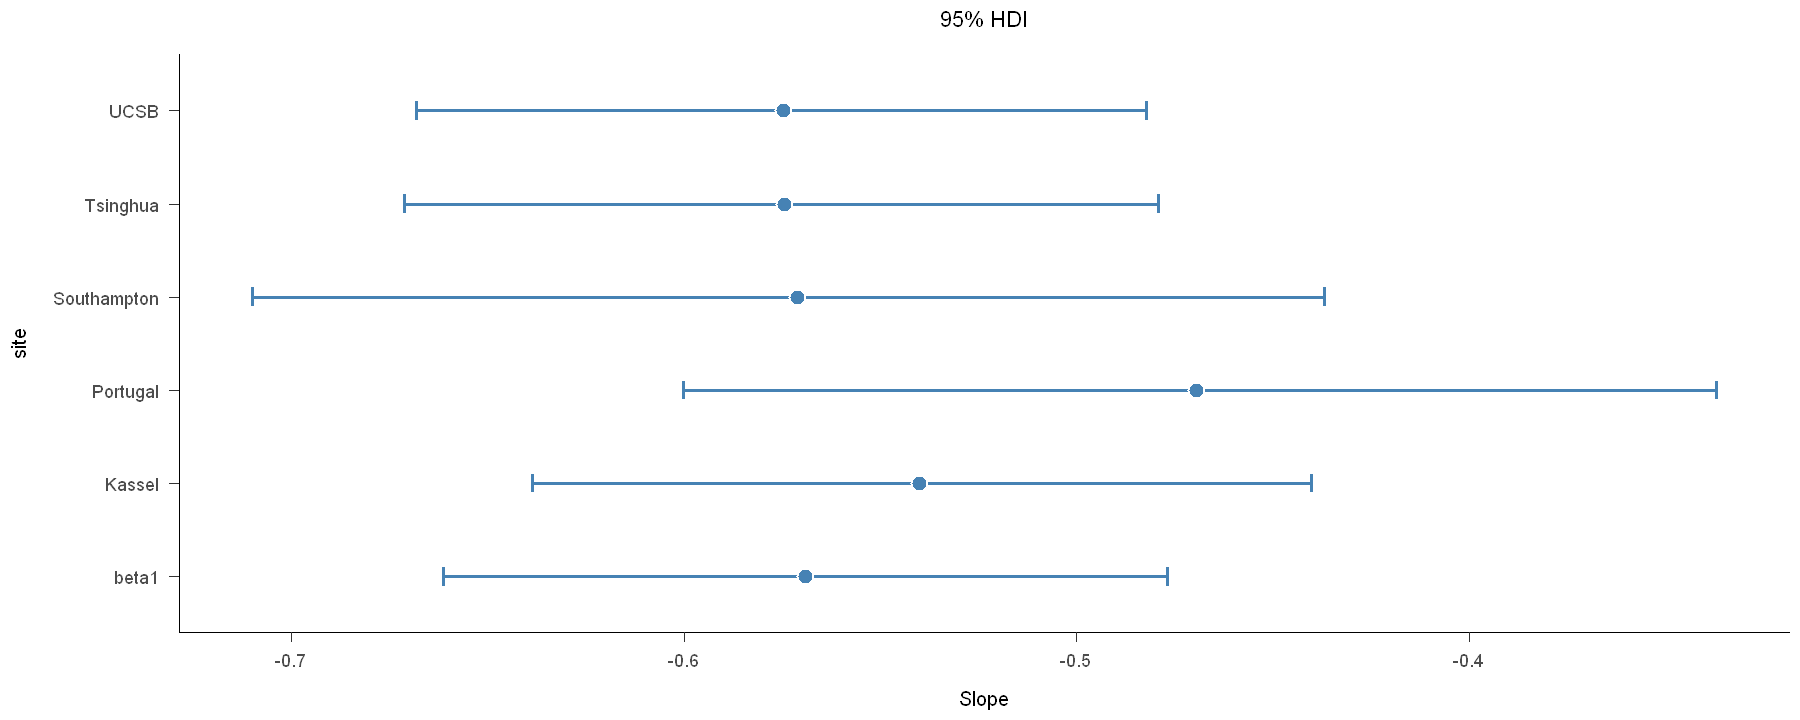

In [87]:
# 可视化
ggplot2::ggplot(plot_hdi2, aes(x = Slope, y = site)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = plot_hdi2$Slope_Q2.5, xmax = plot_hdi2$Slope_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

### 后验预测回归线  

* 5条回归线的截距相同，但是斜率不同

New names:
• `row_idx` -> `row_idx...1`
• `row_idx` -> `row_idx...44`


text[GRID.text.3758] 

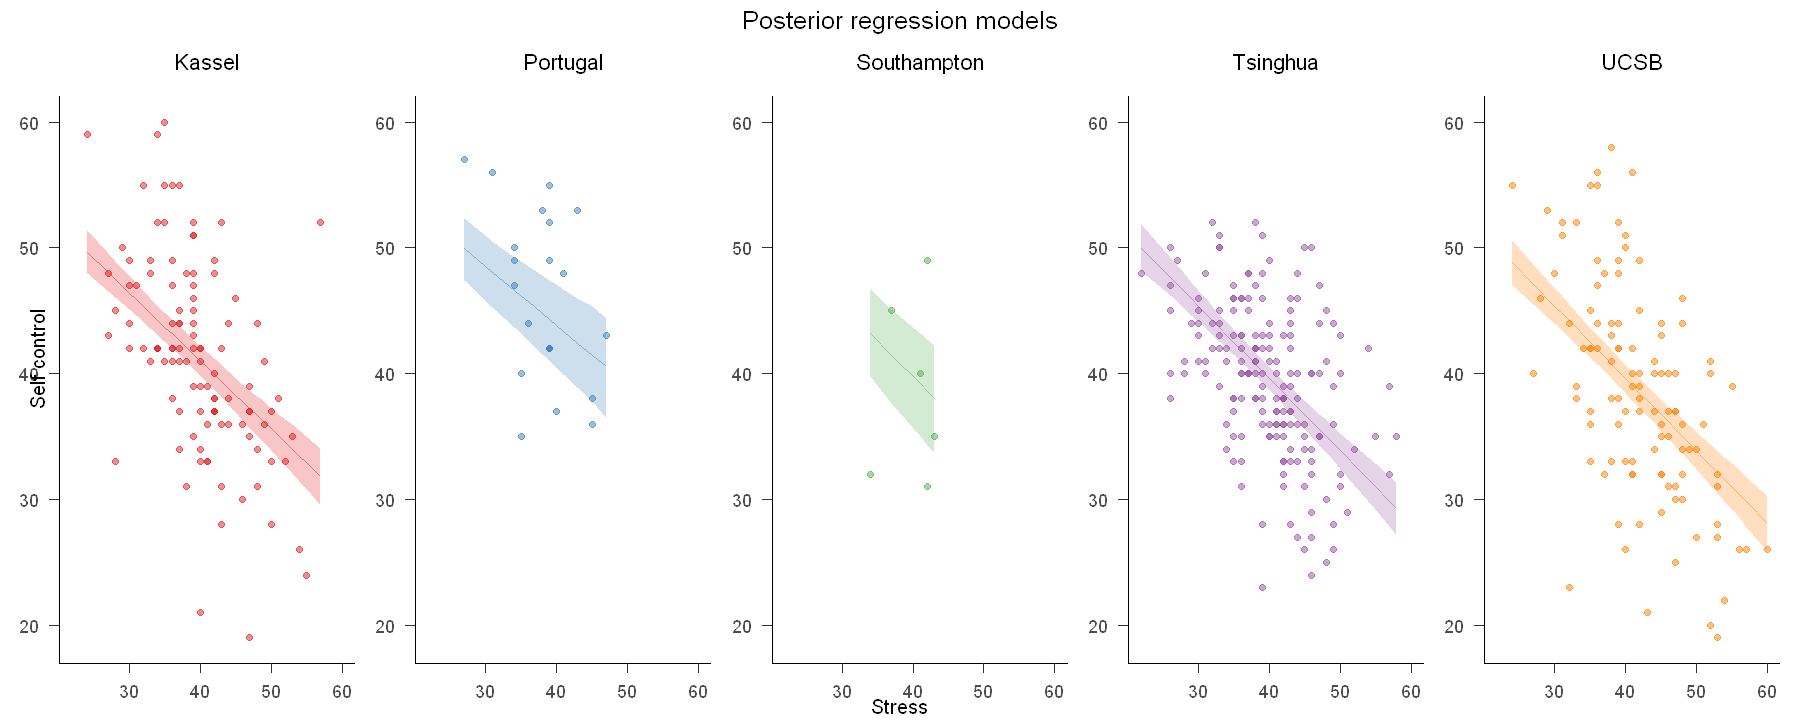

In [88]:
# 获取站点列表
groups <- get_group_index(df_first5)

# 进行可视化
p2 <- plot_regression(data = df_first5, model = var_slope_model, groups = groups)
p2

### 组间方差与组内方差  

* 在这个模型定义中，组间方差来自`beta_1_offset`，组内方差来自`sigma_y`

In [89]:
# 提取随机效应的变异信息
model_var <- brms::VarCorr(var_slope_model)

# 提取组间变异
sd_slope <- model_var$Site$sd[2]      
between_var_slope <- as.numeric(sd_slope)^2

# 3. 提取组内变异（从后验样本计算）
sigma_samples <- brms::posterior_samples(var_inter_model, pars = "sigma")
residual_sd <- mean(sigma_samples$sigma)
within_var <- residual_sd^2

# # 计算变异解释比例
total_var_slope <- between_var_slope + within_var
prop_slope_between <- (between_var_slope / total_var_slope) * 100            # 组间解释百分比
prop_slope_within <- (within_var / total_var_slope) * 100                    # 组内解释百分比


cat("组间方差：", round(between_var_slope, 4), "\n")
cat("组内方差：", round(within_var, 4), "\n")
cat("被组间方差所解释的部分：", round(prop_slope_between, 2), "%\n")
cat("被组内方差所解释的部分：", round(prop_slope_within, 2), "%\n\n")

组间方差： 0.0061 
组内方差： 40.7428 
被组间方差所解释的部分： 0.01 %
被组内方差所解释的部分： 99.99 %



## Model3: Hierarchical model with varying intercepts & slopes  

模型1 和模型2分别考虑了截距和斜率随着站点的变化，在模型3中我们将同时考虑截距和斜率在不同站点间的差异  

$$  
\beta_{0j} | \beta_0, \sigma_0 \sim N(\beta_0, \sigma_0^2)  
\;\;\;\; \text{ and } \;\;\;\;  
\beta_{1j} | \beta_1, \sigma_1 \sim N(\beta_1, \sigma_1^2)  
$$  

**总结模型定义：**  

**prior**

$$  
\begin{array}{rll} 
\mu_{beta_0}  & \sim N(40, 20^2) & \\  
\mu_{beta_1}  & \sim N(0, 5^2) & \\  
\sigma_0 & \sim \text{Exp}(1)    & \\  
\sigma_1 & \sim \text{Exp}(1)    & \\  
\sigma_y & \sim \text{Exp}(1)   & \\  
\end{array}  
$$ 

**likelihood**

$$  
\begin{array}{rll}
\beta_{0j} | \beta_0, \sigma_0  & \stackrel{ind}{\sim} N(\mu_{beta_0}, \sigma_0^2) & \text{Layer 2: 全局水平（表示截距在站点间的变化）} \\ 
\beta_{1j} | \beta_1, \sigma_1  & \stackrel{ind}{\sim} N(\mu_{beta_1}, \sigma_1^2)  & \text{Layer 2: 全局水平（表示斜率在站点间的变化）} \\  
Y_{ij} | \beta_{0j}, \beta_{1j}, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_{1j} X_{ij}& \text{Layer 1: 被试水平（表示每个站点内的线性模型）} \\  
\end{array}  
$$


**分层模型与非池化模型的对比**  

|     | 分层模型                                                        | 非池化模型                                                       |
| --- | ----------------------------------------------------------- | ----------------------------------------------------------- |
| 相同  | $Y_{ij} \sim N(\beta_{0j} + \beta_{1j} X_{ij}, \sigma_y^2)$ | $Y_{ij} \sim N(\beta_{0j} + \beta_{1j} X_{ij}, \sigma_y^2)$ |
| 不同  | $\beta_{0j} \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2)$    | $\beta_{0j} \stackrel{ind}{\sim} N(40, 20^2)$                |
|     | $\beta_{1j} \stackrel{ind}{\sim} N(\beta_1, \sigma_1^2)$    | $\beta_{1j} \stackrel{ind}{\sim} N(0, 5^2)$                 |
|     | $\beta_{0} \sim N(40, 20^2)$                                 | $\sigma_y \sim \text{Exp}(1)$                               |
|     | $\beta_1 \sim N(0, 5^2)$                                    |                                                             |
|     | $\sigma_0 \sim \text{Exp}(1)$                               |                                                             |
|     | $\sigma_1 \sim \text{Exp}(1)$                               |                                                             |
|     | $\sigma_y \sim \text{Exp}(1)$                               |                                                             |

* 在非池化模型中，我们认为截距、斜率和变异在不同站点间是不同的；  
* 但在层级模型中，我们额外考虑了来自总体的的信息，即不同站点间的斜率/截距是从全局参数的斜率/截距中抽样的。  
	* 注意，在层级模型中一般不会假设*变异会随着分组变量变化*，这也是分层模型和非池化模型的重要区别。  


In [5]:
var_both_model <- brms::brm(
  scontrol ~ 1 + stress + (stress | Site), # 随机截距 + 随机斜率
  data = df_first5,
  family = gaussian(),
  iter = 5000,
  warmup = 1000,
  chains = 4,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000164 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 1.64 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 5000 [  0%]  (Warmup)
Chain 1: Iteration:  500 / 5000 [ 10%]  (Warmup)
Chain 1: Iteration: 1000 / 5000 [ 20%]  (Warmup)
Chain 1: Iteration: 1001 / 5000 [ 20%]  (Sampling)
Chain 1: Iteration: 1500 / 5000 [ 30%]  (Sampling)
Chain 1: Iteration: 2000 / 5000 [ 40%]  (Sampling)
Chain 1: Iteration: 2500 / 5000 [ 50%]  (Sampling)
Chain 1: Iteration: 3000 / 5000 [ 60%]  (Sampling)
Chain 1: Iteration: 3500 / 5000 [ 70%]  (Sampling)
Chain 1: Iteration: 4000 / 5000 [ 80%]  (Sampling)
Chain 1: Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain 1: Iteration: 5000 / 5000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 11.204 seconds (Warm-up)
Chain 1:                37.44 seconds (Sampling)
Chain 1:            

###  MCMC采样&后验参数估计  

* 可以看到5条回归线的斜率$\beta_{1j}$、截距$\beta_{0j}$都是不同的  
* $\beta_{1j}$、$\beta_{0j}$是在总体$\beta_{1}$、$\beta_{0}$上增加了一些变异

In [91]:
summary(var_both_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: scontrol ~ 1 + stress + (stress | Site) 
   Data: df_first5 (Number of observations: 415) 
  Draws: 4 chains, each with iter = 5000; warmup = 1000; thin = 1;
         total post-warmup draws = 16000

Multilevel Hyperparameters:
~Site (Number of levels: 5) 
                      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(Intercept)             4.71      3.14     0.35    12.48 1.00     3864
sd(stress)                0.11      0.08     0.01     0.33 1.00     2996
cor(Intercept,stress)    -0.44      0.51    -0.99     0.81 1.00     5154
                      Tail_ESS
sd(Intercept)             4097
sd(stress)                5026
cor(Intercept,stress)     8337

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    63.41      3.34    56.68    70.37 1.00     7043     7188
stress       -0.57      0.08    -0.74    -0.40 1.00     5688     5794

Further Distribution

In [ ]:
site_coef3 <- as.data.frame(stats::coef(var_both_model))

#整理数据
coef_df3 <- as.data.frame(summary(var_both_model)$fixed)
#截距
Intercept_hdi <- site_coef3 %>%
  dplyr::select(1:4) %>%
  dplyr::rename(Intercept = 1, 
         Intercept_error = 2, 
         Intercept_Q2.5 = 3, 
         Intercept_Q97.5 = 4) %>%
  dplyr::bind_rows(
    data.frame(Intercept = coef_df3$Estimate, Intercept_error = coef_df3$Est.Error, 
               Intercept_Q2.5 = coef_df3$`l-95% CI`, Intercept_Q97.5 = coef_df3$`u-95% CI`) %>%
      slice(1)
  )
rownames(Intercept_hdi)[nrow(Intercept_hdi)] <- "beta0"
Intercept_hdi <- Intercept_hdi %>%
  tibble::rownames_to_column("site")

#斜率
Slope_hdi <- site_coef3 %>%
  dplyr::select(5:8) %>%
  dplyr::rename(slope = 1, 
         slope_error = 2, 
         slope_Q2.5 = 3, 
         slope_Q97.5 = 4) %>%
  dplyr::bind_rows(
    data.frame(slope = coef_df3$Estimate, slope_error = coef_df3$Est.Error, 
               slope_Q2.5 = coef_df3$`l-95% CI`, slope_Q97.5 = coef_df3$`u-95% CI`) %>%
      slice(2)
  )
rownames(Slope_hdi)[nrow(Slope_hdi)] <- "beta1"
Slope_hdi <- Slope_hdi %>%
  tibble::rownames_to_column("site")

coef_combined <- Intercept_hdi %>%
  # 按site列内连接Slope_hdi
  dplyr::inner_join(Slope_hdi, by = "site") # %>%

# 查看合并后的结果
print(coef_combined)

         site Intercept Intercept_error Intercept_Q2.5 Intercept_Q97.5
1 Southampton  62.09320        5.154576       50.58261        72.15736
2    Portugal  66.19963        4.952332       57.11529        77.15783
3      Kassel  64.60697        2.975640       59.18231        70.93983
4    Tsinghua  59.69801        3.044076       53.29007        65.17000
5        UCSB  64.93258        3.250506       59.19901        71.76067
       slope slope_error slope_Q2.5 slope_Q97.5
1 -0.5660076  0.12479945 -0.8200293  -0.2947472
2 -0.5492916  0.12761548 -0.8251560  -0.2998636
3 -0.5875393  0.07350263 -0.7431633  -0.4536836
4 -0.5057575  0.07502438 -0.6409590  -0.3480659
5 -0.6282807  0.07667325 -0.7887208  -0.4934592


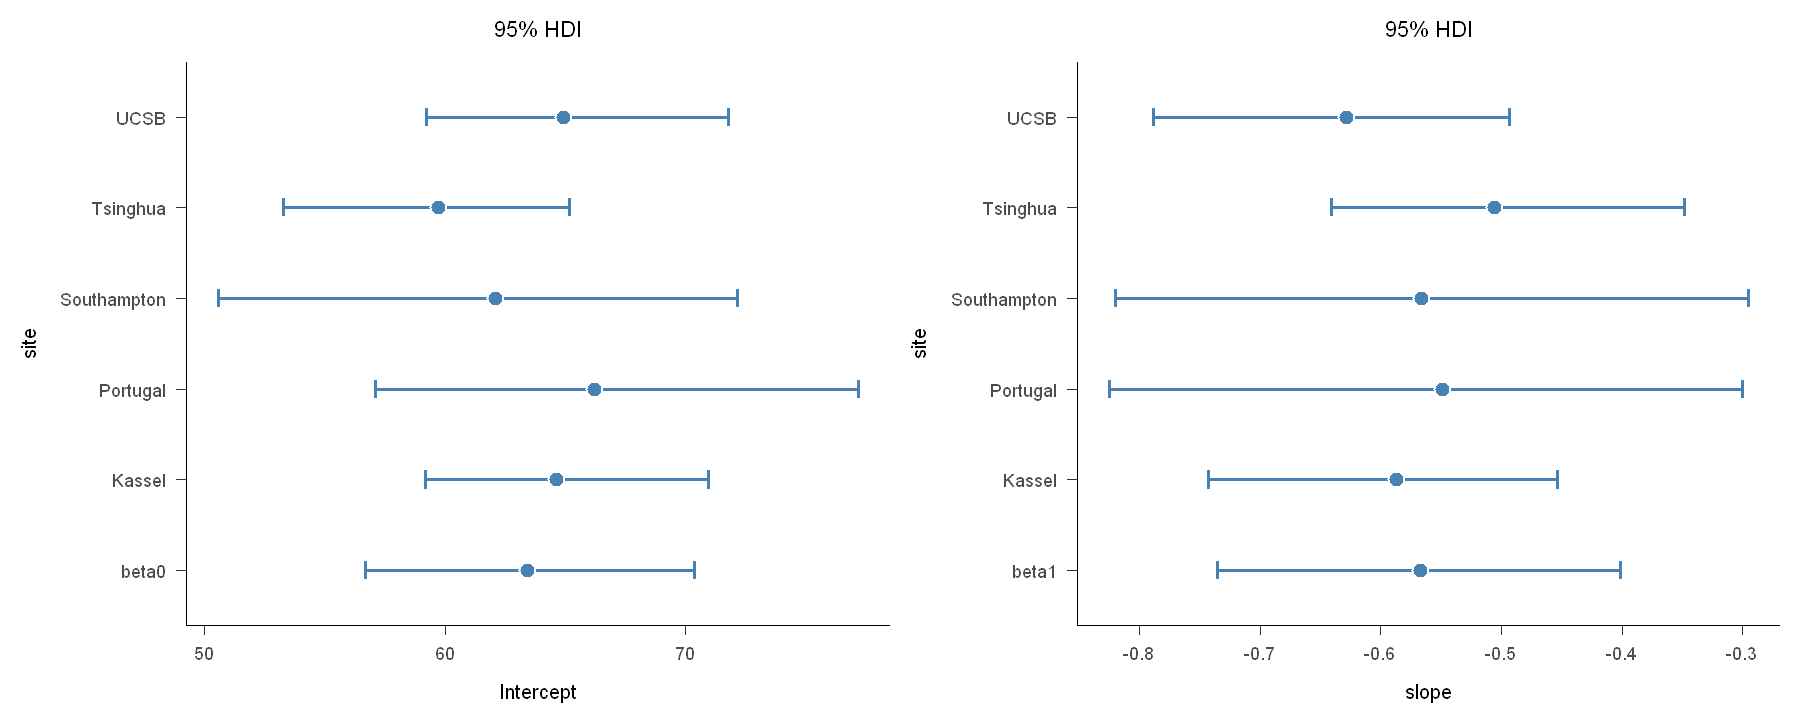

In [8]:
# 可视化
options(repr.plot.width = 15, repr.plot.height = 6)

int_plot <- ggplot2::ggplot(Intercept_hdi, aes(x = Intercept, y = site)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = Intercept_hdi$Intercept_Q2.5, xmax = Intercept_hdi$Intercept_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

slop_plot <- ggplot2::ggplot(Slope_hdi, aes(x = slope, y = site)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = Slope_hdi$slope_Q2.5, xmax = Slope_hdi$slope_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

int_plot + slop_plot

### 后验预测回归线  
* 5条回归线的截距、斜率都是不同的

New names:
• `row_idx` -> `row_idx...1`
• `row_idx` -> `row_idx...44`


text[GRID.text.434] 

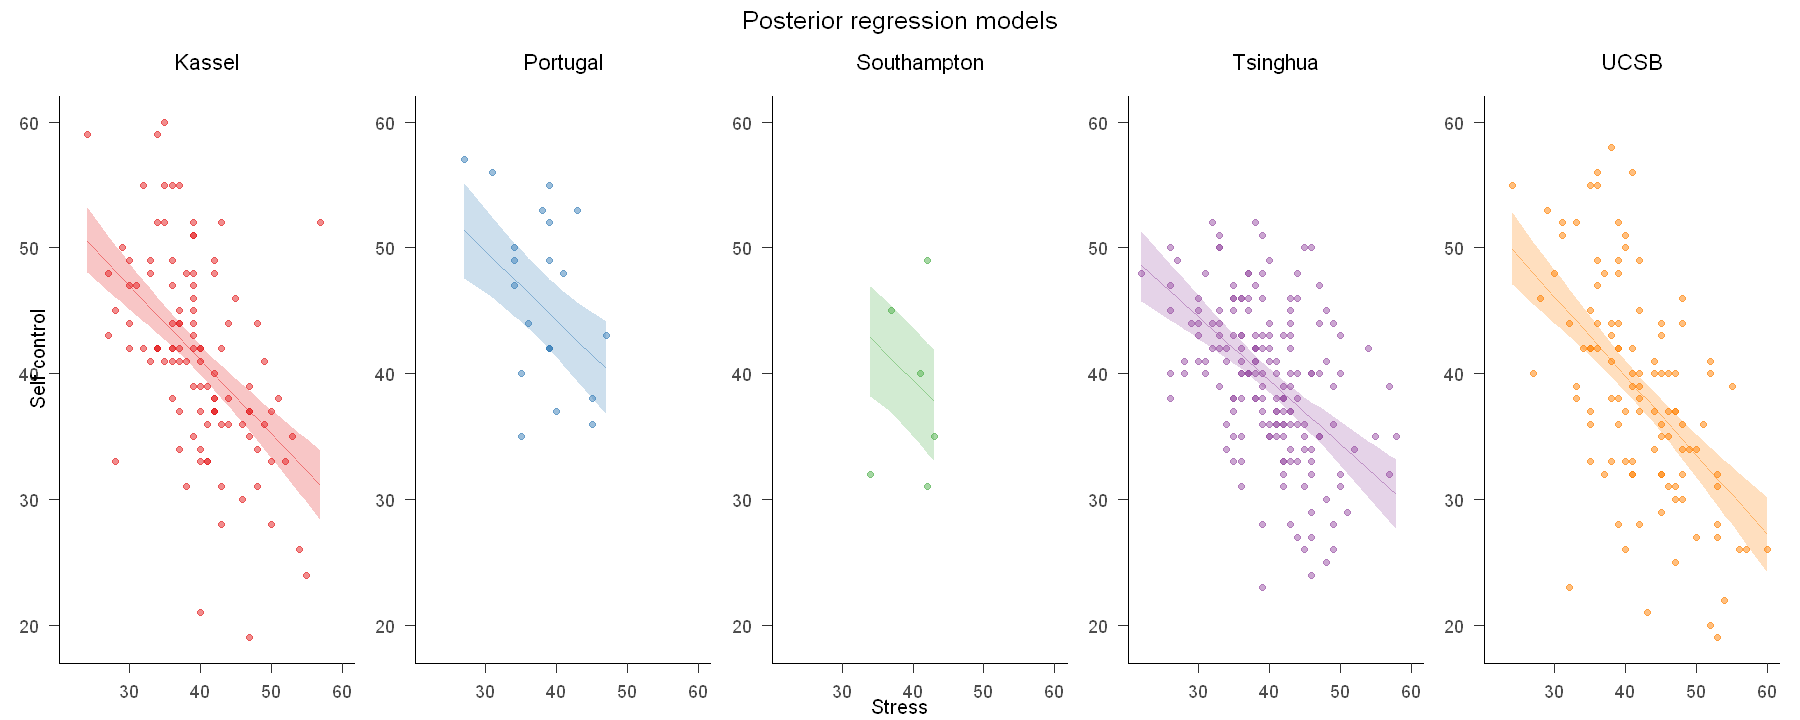

In [11]:
# 获取站点列表
groups <- get_group_index(df_first5)

# 进行可视化
p3 <- plot_regression(data = df_first5, model = var_both_model, groups = groups)
p3

### 组间方差与组内方差  

* 在这个模型定义中，组间方差来自`beta_0_offset`、`beta_1_offset`，组内方差来自`sigma_y`

In [100]:
# 提取随机效应的变异信息
model_var <- brms::VarCorr(var_both_model)

# 提取组间变异
sd_intercept <- model_var$Site$sd[1]  
between_var_intercept <- as.numeric(sd_intercept)^2

sd_slope <- model_var$Site$sd[2]      
between_var_slope <- as.numeric(sd_slope)^2

# 提取组内变异
sigma_samples <- brms::posterior_samples(var_both_model, pars = "sigma")
residual_sd <- mean(sigma_samples$sigma)
within_var <- residual_sd^2

# 计算截距的变异解释比例
total_var_intercept <- between_var_intercept + within_var
prop_intercept_between <- (between_var_intercept / total_var_intercept) * 100  # 组间解释百分比
prop_intercept_within <- (within_var / total_var_intercept) * 100            # 组内解释百分比

# 计算斜率的变异解释比例
total_var_slope <- between_var_slope + within_var
prop_slope_between <- (between_var_slope / total_var_slope) * 100            # 组间解释百分比
prop_slope_within <- (within_var / total_var_slope) * 100                    # 组内解释百分比

# 打印结果
cat("=== 截距的变异解释比例 ===\n")
cat("截距的组间方差：", round(between_var_intercept, 4), "\n")
cat("组内方差：", round(within_var, 4), "\n")
cat("截距的组间解释比例：", round(prop_intercept_between, 2), "%\n")
cat("截距的组内解释比例：", round(prop_intercept_within, 2), "%\n\n")

cat("=== 斜率的变异解释比例 ===\n")
cat("斜率的组间方差：", round(between_var_slope, 4), "\n")
cat("组内方差：", round(within_var, 4), "\n")
cat("斜率的组间解释比例：", round(prop_slope_between, 2), "%\n")
cat("斜率的组内解释比例：", round(prop_slope_within, 2), "%\n")

=== 截距的变异解释比例 ===
截距的组间方差： 22.2306 
组内方差： 40.7536 
截距的组间解释比例： 35.3 %
截距的组内解释比例： 64.7 %

=== 斜率的变异解释比例 ===
斜率的组间方差： 0.0126 
组内方差： 40.7536 
斜率的组间解释比例： 0.03 %
斜率的组内解释比例： 99.97 %


## 小结

现在，我们可以看到在三种不同情况下的部分池化模型的后验预测回归线。  

可以发现三个模型之间存在差异，我们可以对其模型进行评估。  


<div align="center">  
  <img src="https://cdn.kesci.com/upload/soo4ix6oj8.png?imageView2/0/w/700" alt="Image">  
</div>  

<div style="padding-bottom: 60px;"></div>

## 评估后验预测  

* 在之前的课程中，我们介绍过对后验预测结果进行评估的两种方法  

* 一是**MAE**，即后验预测值与真实值之间预测误差的中位数，二是**within_95**，即真实值是否落在95%后验预测区间内  

* 在这里我们调用之前写过的计算两种指标的方法，评估四个模型的后验预测结果

In [101]:
# 对完全池化模型进行后验预测
complete_ppc <- posterior_predict(
  object = complete_pooled_model,
  seed = 84735
)

# 对仅截距随机模型进行后验预测
var_inter_ppc <- posterior_predict(
  object = var_inter_model,
  seed = 84735
)

# 对仅斜率随机模型进行后验预测
var_slope_ppc <- posterior_predict(
  object = var_slope_model,
  seed = 84735
)

# 对截距+斜率随机模型进行后验预测
var_both_ppc <- posterior_predict(
  object = var_both_model,
  seed = 84735
)

### 绝对指标：MAE (Median Absolute Error)

In [203]:
# 定义计算MAE的函数
calculate_MAE <- function(model_ppc, original_data, y_var = "scontrol") {
  # 计算每个观测的后验预测均值
  pre_y_mean <- colMeans(model_ppc)
  
  # 构建数据框：预测均值 + 原始观测值
  MAE_df <- data.frame(
    scontrol_ppc_mean = pre_y_mean,
    scontrol_original = original_data[[y_var]]  # 提取指定的响应变量观测值
  )
  
  # 计算绝对预测误差
  MAE_df <- MAE_df %>%
    mutate(pre_error = abs(scontrol_original - scontrol_ppc_mean))
  
  # 计算误差的中位数
  MAE_value <- median(MAE_df$pre_error, na.rm = TRUE)
  
  return(MAE_value)
}

In [204]:
complete_pooled_mae <- calculate_MAE(complete_ppc, complete_pooled_model$data, "scontrol")
var_inter_mae <- calculate_MAE(var_inter_ppc, var_inter_model$data, "scontrol")
var_slope_mae <- calculate_MAE(var_slope_ppc, var_slope_model$data, "scontrol")
var_both_mae <- calculate_MAE(var_both_ppc, var_both_model$data, "scontrol")

# 汇总所有模型的MAE
mae_summary <- data.frame(
  model = c("complete_pooled", "var_inter", "var_slope", "var_both"),
  mae = c(complete_pooled_mae, var_inter_mae, var_slope_mae, var_both_mae)
)
print(mae_summary)

            model      mae
1 complete_pooled 3.892723
2       var_inter 4.023589
3       var_slope 3.939613
4        var_both 3.944484


### 相对指标：ELPD-LOO

从模型比较的结果，我们可以发现：  
* 同时包含变化截距和变化斜率的模型(model3)是最优模型，对应了我们的假设3（H3）。  
* 此外，所有模型的 elpd 都非常接近 (考虑到 se大于为15~16)，因此，模型比较的结果只能作为参考，更重要的是通过后验预测检验模型的性能。  

模型假设：  
* H0(model 0)，普通线性模型，仅考虑压力对自我控制的影响。  
* H1(model 1)，变化截距模型，在模型0的基础上考虑自我控制在不同站点的变化。  
* H2(model 2)，变化斜率模型，在模型0的基础上不同站点间的压力影响的变化。  
* H3(model 3)，变化截距和斜率模型，结合模型1和模型2，同时考虑站点对自我控制以及压力影响的变化。

In [162]:
# 计算各模型的LOO
loo0 <- loo::loo(complete_pooled_model)
loo1 <- loo::loo(var_inter_model)
loo2 <- loo::loo(var_slope_model)
loo3 <- loo::loo(var_both_model)

# 比较模型的LOO
loo::loo_compare(loo0, loo1, loo2, loo3)

,elpd_diff,se_diff,elpd_loo,se_elpd_loo,p_loo,se_p_loo,looic,se_looic
var_both_model,0.000000,0.000000,-1362.448,16.12990,8.948869,1.0967009,2724.895,32.25979
var_inter_model,-1.579483,1.529751,-1364.027,16.05753,6.849371,0.7271567,2728.054,32.11506
var_slope_model,-1.852959,1.422910,-1364.301,15.86157,7.379896,0.8246038,2728.601,31.72315
complete_pooled_model,-5.621548,3.647833,-1368.069,15.78303,3.332021,0.4572129,2736.138,31.56605


## 预测新站点的数据  

* 我们可以根据当前的层级模型对新组别的数据进行预测，如"Zurich"站点  

In [12]:
# 生成Zurich站点数据并添加索引
new_group <- df_raw %>%
  dplyr::filter(Site == "Zurich") %>%
  dplyr::mutate(
    obs_id = 0:(dplyr::n() - 1),
    site_idx = as.integer(factor(Site)) - 1
  )

In [13]:
hier_pred_model <- brms::brm(
  scontrol ~ 1 + stress + (1 + stress | Site),
  data = new_group,
  family = gaussian(),
  chains = 4,
  iter = 5000,
  warmup = 1000,
  seed = 84735
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 6.7e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.67 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 5000 [  0%]  (Warmup)
Chain 1: Iteration:  500 / 5000 [ 10%]  (Warmup)
Chain 1: Iteration: 1000 / 5000 [ 20%]  (Warmup)
Chain 1: Iteration: 1001 / 5000 [ 20%]  (Sampling)
Chain 1: Iteration: 1500 / 5000 [ 30%]  (Sampling)
Chain 1: Iteration: 2000 / 5000 [ 40%]  (Sampling)
Chain 1: Iteration: 2500 / 5000 [ 50%]  (Sampling)
Chain 1: Iteration: 3000 / 5000 [ 60%]  (Sampling)
Chain 1: Iteration: 3500 / 5000 [ 70%]  (Sampling)
Chain 1: Iteration: 4000 / 5000 [ 80%]  (Sampling)
Chain 1: Iteration: 4500 / 5000 [ 90%]  (Sampling)
Chain 1: Iteration: 5000 / 5000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 2.066 seconds (Warm-up)
Chain 1:                2.268 seconds (Sampling)
Chain 1:              

In [177]:
summary(hier_pred_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: scontrol ~ 1 + stress + (1 + stress | Site) 
   Data: new_group (Number of observations: 40) 
  Draws: 4 chains, each with iter = 5000; warmup = 1000; thin = 1;
         total post-warmup draws = 16000

Multilevel Hyperparameters:
~Site (Number of levels: 1) 
                      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS
sd(Intercept)             4.17      4.13     0.13    15.93 1.02      168
sd(stress)                0.64      0.76     0.01     3.26 1.07       46
cor(Intercept,stress)    -0.07      0.58    -0.95     0.94 1.02      153
                      Tail_ESS
sd(Intercept)              298
sd(stress)                  24
cor(Intercept,stress)     2450

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    61.34      8.10    45.33    77.25 1.02      149       65
stress       -0.55      0.23    -0.99    -0.16 1.02      132      445

Further Distribut

### 组内预测 vs 组外预测  

* 现在，对于原有站点和新站点，通过MCMC采样，我们都得到了对应站点下对斜率和截距的估计  

    * 在原有站点中，斜率和截距的变量名为beta_0j，beta_1j；在新站点中二者的名字则为new_beta_0j，new_beta_1j  

* 假设我们想知道当压力分数为40时，自我控制分数为多少，那么可以根据 $\mu_{ij} = \beta_{0j} + \beta_{1j} \cdot 40$ 对该数据点的观测值做出预测  

* 在MCMC采样中，对于每个站点，都生成了20000对参数估计值，$\left\lbrace \beta_{0j}^{(i)}, \beta_1^{(i)}\right\rbrace$。因此，代入X值后，对于每个站点我们都能获得20000个对应的预测值

In [47]:
# 构造新数据：stress=40，包含所有站点
new_data <- expand.grid(
  stress = 40,
  Site = base::unique(df_first5$Site)
)

# 生成后验预测值（后验样本×观测值）
post_pred <- brms::posterior_predict(
  object = var_both_model,
  newdata = new_data,
  seed = 84735
)

pred_old <- as.data.frame(post_pred)
colnames(pred_old) <- new_data$Site

# 整理结果
scontrol_by_site <- data.frame(
  Site = new_data$Site,
  mean_pred = colMeans(post_pred),
  l95 = apply(post_pred, 2, quantile, 0.025),
  u95 = apply(post_pred, 2, quantile, 0.975)
)

In [49]:
# 构造新站点新数据（stress=40）
new_data <- expand.grid(
  stress = 40,
  Site = base::unique(new_group$Site)
)

# 生成后验预测值（后验样本×观测值）
post_pred_new <- brms::posterior_predict(
  object = hier_pred_model,
  newdata = new_data,
  seed = 84735
)

pred_new <- as.data.frame(post_pred_new)
colnames(pred_new) <- new_data$Site

# 整理结果
scontrol_by_newSite <- data.frame(
  Site = new_data$Site,
  mean_pred = colMeans(post_pred_new),
  l95 = apply(post_pred_new, 2, quantile, 0.025),
  u95 = apply(post_pred_new, 2, quantile, 0.975)
)

# 合并数据
result_combined <- dplyr::bind_rows(scontrol_by_site, scontrol_by_newSite)

result_combined

Site,mean_pred,l95,u95
<fct>,<dbl>,<dbl>,<dbl>
Kassel,41.12471,28.43656,53.95865
Portugal,44.27532,31.58647,57.09879
Southampton,39.44954,26.18950,52.73165
Tsinghua,39.46670,26.84557,52.28970
UCSB,39.73740,27.08857,52.39049
Zurich,38.66978,25.60722,51.61010


**绘制预测密度分布图**  

* 最后，我们绘制每个站点的预测结果分布  

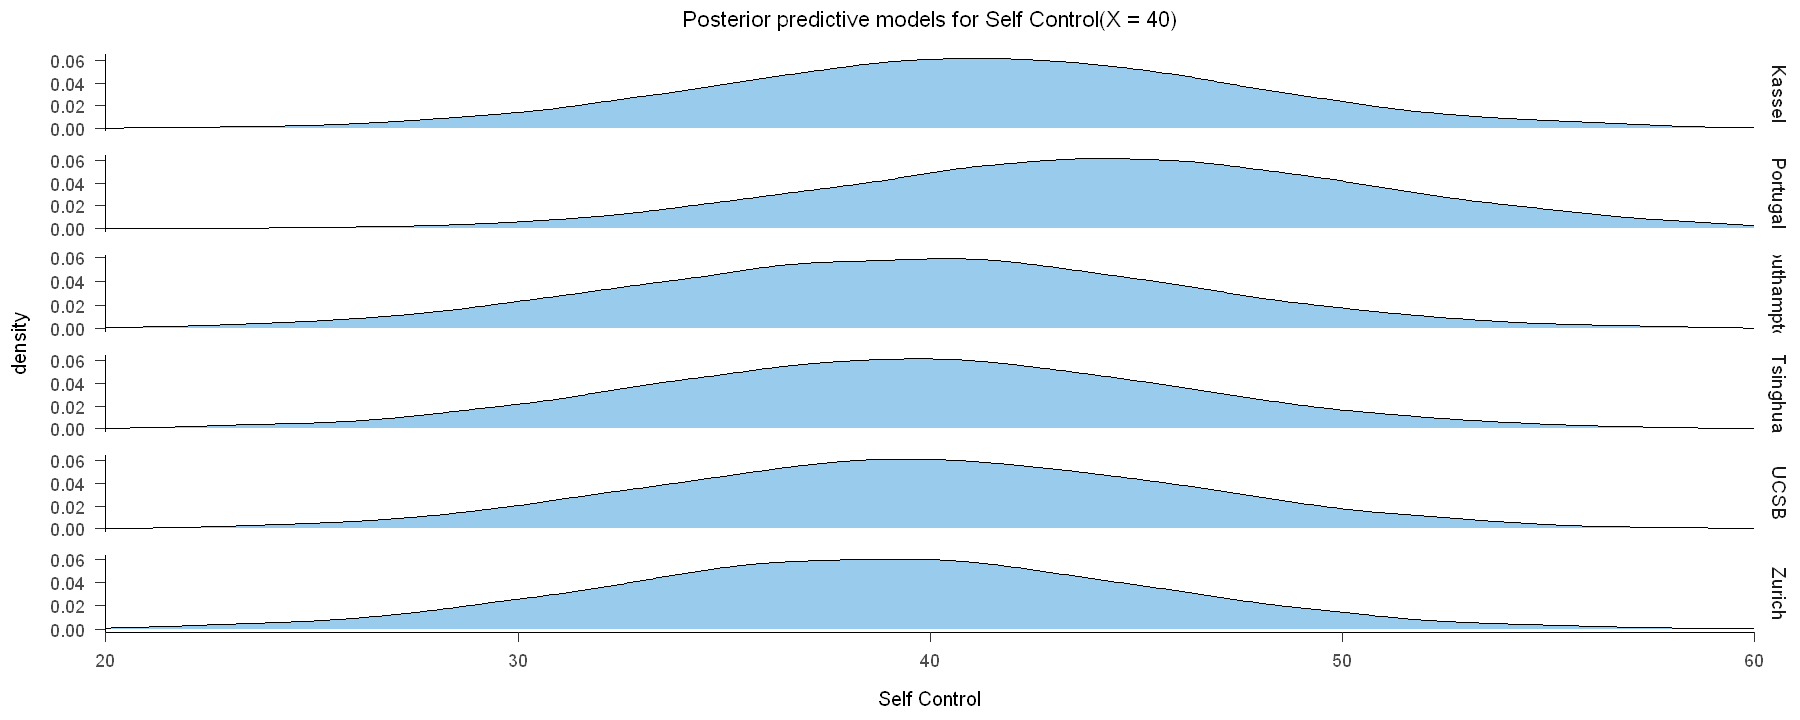

In [54]:
# 合并绘图数据
pred_combined <- dplyr::bind_cols(pred_old, pred_new)

# 转换为长格式
pred_long <- pred_combined %>%
  dplyr::mutate(sample_id = dplyr::row_number()) %>%
  tidyr::pivot_longer(
    cols = -sample_id,
    names_to = "Site",
    values_to = "scontrol_pred"
  ) %>%
  dplyr::select(-sample_id)

# 进行可视化
p <- ggplot2::ggplot(pred_long, ggplot2::aes(x = scontrol_pred)) +
  ggplot2::geom_density(fill = "#3498db", alpha = 0.5, adjust = 1.2) +
  ggplot2::facet_grid(Site ~ ., scales = "free_y") +
  ggplot2::scale_x_continuous(limits = c(20, 60), expand = c(0, 0)) +
  ggplot2::labs(
    x = "Self Control",
    title = "Posterior predictive models for Self Control(X = 40)"
  ) +
  papaja::theme_apa()
p

## 分层模型中的组层面预测因子(group-level predictors)  

🤔 在上面的例子中，我们考虑了个体压力对于自我控制的影响，并且分不同站点来考虑这一问题。然而，我们是否考虑过不同站点的其他特性对于自我控制的影响呢？  

* 例如，原数据想要探究的核心问题为温度和社会行为的关系，不同站点对应了不同国家和地区，而这些地区的平均气温是否会对自我控制产生影响呢？  

    * 由于该数据的收集时间为夏季，因此我们查阅了每一站点的夏季平均气温，作为组层面的预测变量  

* 组层面预测因子(group-level predictors)是指在组间(站点)层面的特征，这是相对于组内预测因子(group-level predictors)而言的。  
    * 例如，个体压力分数(stress)是组内预测因子。这个值在不同个体间具有不同值。  
    * 而地区的夏季平均温度是组层面预测因子。这些值在不同站点(site)间不同，但是在站点内的个体间保持相同。  

![Image Name](https://cdn.kesci.com/upload/s5wfm7n7r8.png?imageView2/0/w/960/h/960)  

### 构建具有组层面预测因子的分层模型  

* 我们在**变化截距**模型的基础上继续添加  

* 回顾之前的仅包含变化的截距的分层模型：  

**prior**

$$  
\begin{array}{rll}  
\beta_{0}  & \sim N(0, 50^2) & \text{} \\  
\beta_1  & \sim N(0, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_0 & \sim \text{Exp}(1)    & \\  
\end{array} 
$$

**likelihood**
$$  
\begin{array}{rll}
\beta_{0j} | \beta_0, \sigma_0  & \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2) & \text{(Layer2: 站点水平)} \\  
Y_{ij} | \beta_{0j}, \beta_1, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_1 X_{ij} & \text{(Layer1: 被试水平)} \\  
\end{array}  
$$  

🤔 如果我们想考虑组层面预测因子，那么该变量该放在哪一层(Layer)？  
* 由于组层面预测因子是组间(站点$j$)层面的特征，因此该变量主要影响截距在站点间的变化。  
* 公式写作： $\beta_{0j} = \gamma_0 + \gamma_1 U_j$  
  * 其中，$U_j$是站点$j$的组层面预测因子  
  * $\gamma_1$是组层面预测因子$U_j$的回归系数；而$\gamma_0$为站点间的变化的截距。  
  * 因此，每个站点的截距 $\beta_{0j}$，受到组层面的预测因子$U_j$的影响。  
* 也可以写作 $\mu_{ij} = \beta_{0j} + \beta_1 X_{ij} = (\gamma_0 + \gamma_1 U_j) + \beta_1 X_{ij}$

In [57]:
# 选择变量并重置索引
df_temp <- df_first5 %>%
  dplyr::select(site_idx, obs_id, Site, stress, scontrol) %>%
  tibble::remove_rownames()

# 定义站点-气温映射
levels <- base::unique(df_temp$Site)
level_mapping <- base::c(17.6, 24.8, 19.9, 30.3, 19)
names(level_mapping) <- levels

# 添加气温列
df_temp <- df_temp %>%
  dplyr::mutate(
    avetemp = dplyr::recode(Site, !!!level_mapping)
  )

# 查看结果
df_temp[1:5, ]

,site_idx,obs_id,Site,stress,scontrol,avetemp
,<dbl>,<dbl>,<fct>,<int>,<int>,<dbl>
1,2,0,Kassel,30,47,17.6
2,2,1,Kassel,30,44,17.6
3,2,2,Kassel,31,47,17.6
4,2,3,Kassel,47,37,17.6
5,2,4,Kassel,50,33,17.6


### 夏季平均气温对自我控制平均分的影响  

    * 由于我们只考虑了5个站点的数据，因此也只有5个数据点

`geom_smooth()` using formula = 'y ~ x'


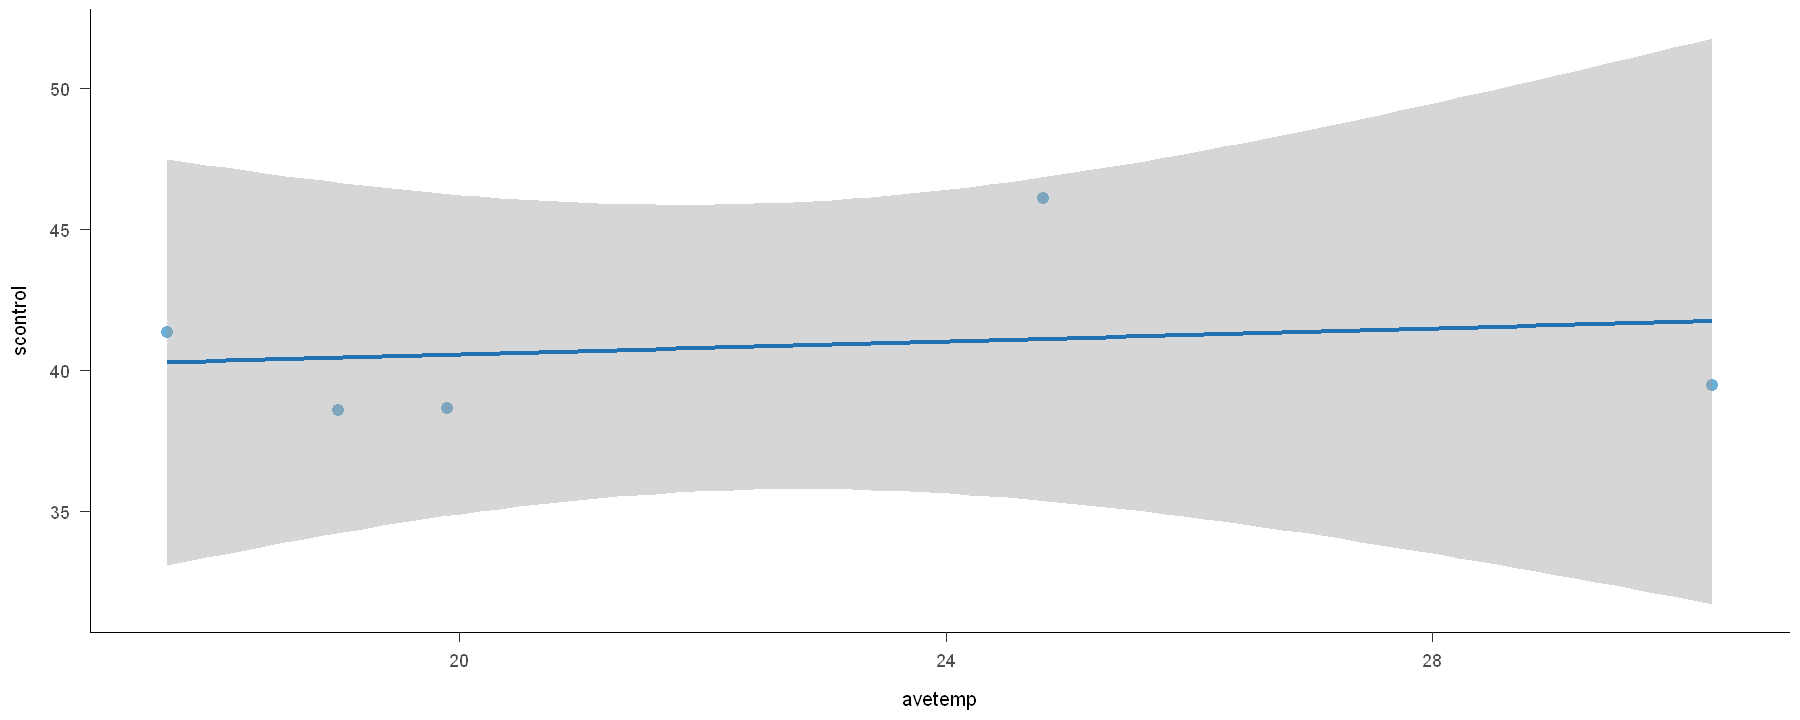

In [68]:
# 按站点分组求均值
df_grouped <- df_temp %>%
  dplyr::group_by(Site) %>%
  dplyr::summarise(
    avetemp = base::mean(avetemp, na.rm = TRUE),
    scontrol = base::mean(scontrol, na.rm = TRUE),
    .groups = "drop"
  )

# 绘制回归散点图
p <- ggplot2::ggplot(df_grouped, ggplot2::aes(x = avetemp, y = scontrol)) +
  # 绘制散点
  ggplot2::geom_point(
    size = 3,
    color = "#6BAED6"
  ) +
  # 绘制线性回归拟合线
  ggplot2::geom_smooth(
    method = "lm",
    color = "#2171B5",
    linewidth = 1.2,
  ) +
  papaja::theme_apa()

# 显示图形
p

**总的公式**  

将 $\beta_{0j} = \gamma_0 + \gamma_1 U_j$ 放入之前的公式，并且为新参数$\gamma_0$和$\gamma_1$引入先验分布：  

**prior**  

$$  
\begin{array}{rll}  
\gamma_0  & \sim N(0, 50^2) & \\  
\gamma_1 & \sim N(0, 5^2) & \\  
\beta_1  & \sim N(0, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_0 & \sim \text{Exp}(1)   & \\  
\end{array}  
$$

**likelihood**  

$$  
\begin{array}{rll}
\beta_{0j} | \gamma_0, \gamma_1, \sigma_0  & \stackrel{ind}{\sim} N(\gamma_0 + \gamma_1 U_j, \sigma_0^2) & \text{(Layer2: 站点水平)} \\  
Y_{ij} | \beta_{0j}, \beta_1, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_1 X_{ij} & \text{(Layer1: 被试水平)} \\  
\end{array}  
$$





**另一种定义形式**  

* 在此前我们认为$\beta_{0j}= \beta_0 + b_{0j}$，即在共同截距的基础上增加组的变异  

* 但在具有组层面(group-level)预测因子的模型中，实际上截距又会受到组层面的影响  

    * 相当于：$\beta_{0} = \gamma_0 + \gamma_1 U_j$  

    * $\beta_{0j} = \gamma_0 + \gamma_1 U_j + b_{0j}$  

    * 进一步将 $\beta_{0j}$ 放入 $\mu_{ij} = \beta_{0j} + \beta_1 X_{ij}$中:  
    
* $\mu_{ij} = (\gamma_0 + \gamma_1 U_j + b_{0j}) + \beta_1 X_{ij}$  

* 整理有：  

**prior**

$$  
\begin{array}{rll}  
\gamma_0  & \sim N(40, 20^2) & \\  
\gamma_1 & \sim N(0, 5^2) & \\  
\beta_1  & \sim N(0, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_0 & \sim \text{Exp}(1)   & \\  
\end{array}  
$$  

**likelihood**
$$  
\begin{array}{rll}  
b_{0j} | \sigma_0 & \stackrel{ind}{\sim} N(0, \sigma_0^2) & \text{(Layer2: 站点水平)} \\  
Y_{ij} | \beta_{0j}, \beta_1, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = (\gamma_0 + \gamma_1 U_j + b_{0j}) + \beta_1 X_{ij} & \text{(Layer1: 被试水平)} \\  
\end{array}  
$$  



In [71]:
group_pred_model <- brms::brm(
  scontrol ~ 1 + stress + avetemp + (1 | Site),
  data = df_temp,
  family = gaussian(),
  iter = 2000,
  warmup = 1000,
  chains = 4,
  cores = 4,
  seed = 84735
)

Compiling Stan program...

Start sampling



In [72]:
summary(group_pred_model)

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: scontrol ~ 1 + stress + avetemp + (1 | Site) 
   Data: df_temp (Number of observations: 415) 
  Draws: 4 chains, each with iter = 2000; warmup = 1000; thin = 1;
         total post-warmup draws = 4000

Multilevel Hyperparameters:
~Site (Number of levels: 5) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     3.56      1.87     1.00     8.41 1.01      872      861

Regression Coefficients:
          Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept    62.94      8.90    43.62    81.45 1.01     1223      687
stress       -0.56      0.05    -0.66    -0.47 1.00     3208     2254
avetemp       0.02      0.37    -0.76     0.85 1.01     1175      742

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     6.41      0.22     5.99     6.85 1.00     3539     2773

Draws were sampled using sampling(NUTS). For eac

## 总结  

本节课介绍了如何使用将分层模型扩展到一般线性模型，以及广义线性模型。  

重点内容包括：  
* 如何根据研究问题和假设来确定模型  
* 如何在brm中定义分层模型，包括变化的截距、变化的斜率  
* 如何通过模型比较来检验不同的假设  
* 如何使用分层模型预测其他群体(站点)的结果  

🎉🎉🎉🎉🎉 最后，本课程的正式内容也到此为止，感谢大家参与本门课程，希望大家能在实践中应用课程中的知识和技能，提高自己统计分析的能力。  

通过本课程的学习，大家应该能对贝叶斯工作流有一个初步的理解，这将帮助你们更好地应用贝叶斯方法进行数据分析。  

![Image Name](https://cdn.kesci.com/upload/image/rkz1ehen1l.png?imageView2/0/w/720/h/960)  


本学期贝叶斯课程中使用了许多心理学研究中的示例。如果你们有兴趣查看其他示例研究，可以浏览去年的课件，我们已经将其上传到 GitHub 上，链接如下：  
https://github.com/hcp4715/psybayesian/tree/master/Archive/2023/Notebooks  

<div style="padding-bottom: 30px;"></div>  

## 练习

本次练习以随机点运动范式的数据为例，并引入包含自变量时的层级模型，通过不同的模型验证不同的假设：  

* H0(model 0)，普通线性模型，仅考虑被试的反应时间。  
* H1(model 1)，变化截距模型，在模型0的基础上考虑点运动方向的一致性在不同被试上的变化。  
* H2(model 2)，变化斜率模型，在模型0的基础上不同被试间的反应时间的变化。  
* H3(model 3)，变化截距和斜率模型，结合模型1和模型2，同时考虑被试的反应时间和点运动方向的一致性之间的变化。  

注意，本次练习仅考虑部分池化模型的3种不同情况（即练习 model 1、model 2、model 3）。

In [1]:
# 安装和加载包
options(repos = c(CRAN = "https://mirrors.tuna.tsinghua.edu.cn/CRAN/"))
if (!requireNamespace('pacman', quietly = TRUE)) {
  install.packages('pacman')
}
pacman::p_load("tidyverse","ggplot2", "dplyr","gridExtra","patchwork","papaja", "bayesplot",
               "rstan","bridgesampling", 'logspline', "easystats", "brms", "RColorBrewer", "loo") 
options(warn = -1)  # 抑制警告

The following packages have been unloaded:
easystats


Warning message:
"unable to access index for repository http://www.stats.ox.ac.uk/pub/RWin/bin/windows/contrib/4.3:
  cannot open URL 'http://www.stats.ox.ac.uk/pub/RWin/bin/windows/contrib/4.3/PACKAGES'"



  There is a binary version available but the source version is later:
          binary source needs_compilation
easystats  0.7.4  0.7.5             FALSE



installing the source package 'easystats'


Warning message in utils::install.packages(package, ...):
"installation of package 'easystats' had non-zero exit status"

easystats installed

Warning message in pacman::p_load("tidyverse", "ggplot2", "dplyr", "gridExtra", :
"Failed to install/load:
easystats"


In [2]:
# 导入示例数据
df_raw <- tryCatch({
  read.csv('/home/mw/input/bayes3797/evans2020JExpPsycholLearn_exp1_full_data.csv')
}, error = function(e) {
  read.csv('data/evans2020JExpPsycholLearn_exp1_full_data.csv')
})
df_raw[1:5, c("subject", "RT")] # 显示前五行的数据

,subject,RT
,<int>,<int>
1,31727,3529
2,31727,2242
3,31727,979
4,31727,4526
5,31727,7387


由于被试数量较多，依旧使用其中5个被试的数据作为练习。

In [3]:
# 筛选出特定被试并创建索引
df_first5 <- df_raw %>%
  dplyr::filter(
    subject %in% c(81844, 83956, 83824, 66670, 80941) ,
    percentCoherence %in% c(5, 10) # 筛选特定被试
  ) %>%
  dplyr::group_by(subject) %>%
  dplyr::mutate(
    subj_id = subject,
    obs_id = dplyr::row_number(),
    log_RTs = log(RT),
    global_id = 1 : n()
  ) %>%
  dplyr::ungroup()

# 查看数据
head(df_first5)

subject,blkNum,trlNum,coherentDots,numberofDots,percentCoherence,winningDirection,response,correct,eventCount,averageFrameRate,RT,subj_id,obs_id,log_RTs,global_id
<int>,<int>,<int>,<int>,<int>,<int>,<chr>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,<dbl>,<int>
66670,2,2,2,40,5,left,left,1,23,15.700,1465,66670,1,7.289611,1
66670,2,3,2,40,5,left,left,1,25,15.375,1626,66670,2,7.393878,2
66670,2,4,4,40,10,right,right,1,37,15.346,2411,66670,3,7.787797,3
66670,2,6,2,40,5,left,left,1,16,16.113,993,66670,4,6.900731,4
66670,2,7,4,40,10,left,left,1,16,15.564,1028,66670,5,6.935370,5
66670,2,8,4,40,10,right,right,1,13,16.089,808,66670,6,6.694562,6


和上节课一样，我们需要通过链接函数（link function）来将反应时数据转换为正态分布。

公式为：

$$
\begin{align*}
\eta = \log(RT)  \\
\eta \sim \mathcal{N}(\mu, \sigma)  \\
\end{align*}
$$

* 其中，$\eta$是反应时的对数，$\mu$和$\sigma$是正态分布的均值和标准差。

注意，由于 RT 经过对数变化后其范围缩小，因此我们对先验进行设置时需要对 $\mu$ 和 $\sigma$ 进行缩放，以保持反应时数据的范围。
* 从上图中可以看出，反应时数据经过对数转换后的范围为 [5,10]。
* 因此，先验 $\mu$ 可以设置为 $\mu ~$，先验 $\sigma$ 的可以设置为: 

$$\begin{align*}
\mu \sim \mathcal{N}(7.5, 5)  \\
\sigma \sim Exp(1)  \\
\end{align*}
$$



###  Model1: Hierarchical model with varying intercepts  

相较于没有自变量的分层模型，构建包含自变量的分层模型的关键在于区分 **变量($\beta$)** 和 **分层(layer)** 的关系。  

$$  
\begin{array}{rll} 
\text{priors:} \;\; \;\; \;\; \;\; \beta_{0}  & \sim N(7, 1^2) & \\  
\beta_1  & \sim N(7.5, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_0 & \sim \text{Exp}(1).    & \\  
\beta_{0j} | \beta_0, \sigma_0  & \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2) & \text{(Layer2: 被试水平)} \\  
\text{likelihood:} \;\; \;\; Y_{ij} | \beta_{0j}, \beta_1, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_1 X_{ij} & \text{(Layer1: 试次水平)} \\  
\end{array}  
$$

### Layer 2: Variability between Subject
**1. 随机点运动方向的一致性与反应时间之间的线性关系在被试间有什么不同**  

* 随机点运动方向的一致性与反应时间之间的线性关系由截距和斜率两方面构成  

* 我们认为在不同的被试 $j$ 之间，其截距是变化的  

* 假设截距的基线(baseline)为$\beta_{0}$，不同被试间的组间差异为$\sigma_{0}$，则每个被试的截距可以表示为：  

$$  
\beta_{0j} | \beta_0, \sigma_0 \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2)  .  
$$

### Layer 1: Variability within Subject

**2. 随机点运动方向的一致性与反应时间之间的关系在被试内有什么不同**  

$$  
Y_{ij} | \beta_{j}, \beta_1, \sigma_y \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ where } \; \mu_{ij} = \beta_{0j} + \beta_1 X_{ij}  .  
$$  

* 使用$i$表示第$i$个试次，$i \in (1,2,3...n)$  
* 对于每一个被试来说，其反应时间服从以$\mu_{ij}$为均值，$\sigma_y$为标准差的正态分布  

* 而$\mu_{ij}$由参数$\beta_{0j}$，$\beta_1$决定  

    * 其中，$\beta_{0j}$在组与组之间不同(group-specific)  

    * $\beta_1$和$\sigma_y$则是相同的(global)

### Global priors （变化截距和斜率模型）
**3. 最后，我们考虑截距和斜率共同变化的情况，并全局参数进行定义，即$\beta_{0}, \beta_1,  \sigma_0$**  

$$  
\begin{array}{rll}  
\beta_{0}  & \sim N(m_0, s_0^2)  \\  
\beta_1  & \sim N(m_1, s_1^2) & \\  
\sigma_y & \sim \text{Exp}(l_y)    & \\  
\sigma_0 & \sim \text{Exp}(l_0)    & \\  
\end{array}  

$$

首先，考虑Model 1模型（变化截距）。

In [ ]:
# =================================================
#                    补充...部分
# =================================================

df_first5 <- df_first5 %>% 
  dplyr::mutate(subject = as.factor(subject))

# Model1
var_inter_model <- brms::brm(
  # 模型公式
  formula = ...,
  # 数据
  data = ...,
  # 先验分布设置
  prior = c(
    prior(normal(7, 1), class = Intercept),        # beta0 
    prior(normal(7.5, 5), class = b, coef = percentCoherence), #beta1
    prior(exponential(1), class = sd, group = subject, coef = Intercept), # beta0_sigma           #beta_0_sigma
    prior(exponential(1), class = sigma)           #sigma_y
  ),
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000235 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 2.35 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 23.811 seconds (Warm-up)
Chain 1:                18.21 seconds (Sampling)
Chain 1:                42

### 先验预测检查

In [ ]:
# =================================================
#                    补充...部分
# =================================================

# 定义先验模型
prior_only_model1 <- brms::brm(
  formula = ...,
  data = ...,
  prior = c(
    prior(normal(7, 1), class = Intercept),        
    prior(normal(7.5, 5), class = b, coef = percentCoherence), 
    prior(exponential(1), class = sd, group = subject, coef = Intercept),             #beta_0_sigma
    prior(exponential(1), class = sigma)  
  ),
  chains = 4,
  iter = 1000,
  seed = 84735,
  sample_prior = "only"
)
# 提取先验样本
# 从先验模型中生成预测值
prior_samples1 <- brms::posterior_predict(
  prior_only_model1,
  newdata = df_first5,
  draws = 1000
)
summary(prior_only_model1)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 2.6e-05 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 0.26 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:   1 / 1000 [  0%]  (Warmup)
Chain 1: Iteration: 100 / 1000 [ 10%]  (Warmup)
Chain 1: Iteration: 200 / 1000 [ 20%]  (Warmup)
Chain 1: Iteration: 300 / 1000 [ 30%]  (Warmup)
Chain 1: Iteration: 400 / 1000 [ 40%]  (Warmup)
Chain 1: Iteration: 500 / 1000 [ 50%]  (Warmup)
Chain 1: Iteration: 501 / 1000 [ 50%]  (Sampling)
Chain 1: Iteration: 600 / 1000 [ 60%]  (Sampling)
Chain 1: Iteration: 700 / 1000 [ 70%]  (Sampling)
Chain 1: Iteration: 800 / 1000 [ 80%]  (Sampling)
Chain 1: Iteration: 900 / 1000 [ 90%]  (Sampling)
Chain 1: Iteration: 1000 / 1000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 0.021 seconds (Warm-up)
Chain 1:                0.017 seconds (Sampling)
Chain 1:                0.038 seconds (

 Family: gaussian 
  Links: mu = identity; sigma = identity 
Formula: log_RTs ~ 1 + percentCoherence + (1 | subject) 
   Data: df_first5 (Number of observations: 2326) 
  Draws: 4 chains, each with iter = 1000; warmup = 500; thin = 1;
         total post-warmup draws = 2000

Multilevel Hyperparameters:
~subject (Number of levels: 5) 
              Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sd(Intercept)     1.01      0.99     0.03     3.63 1.00     2554     1211

Regression Coefficients:
                 Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
Intercept          -49.31     37.51  -124.29    24.83 1.00     3442     1310
percentCoherence     7.46      4.96    -2.40    17.48 1.00     3400     1330

Further Distributional Parameters:
      Estimate Est.Error l-95% CI u-95% CI Rhat Bulk_ESS Tail_ESS
sigma     1.01      1.00     0.03     3.93 1.00     2712      977

Draws were sampled using sampling(NUTS). For each parameter, Bulk_ESS
and Tail_ESS are eff

In [6]:
# 定义函数：绘制分站点的先验预测回归线集合
plot_prior1 <- function(prior_only_model, data) {
  # 提取先验预测的mu值
  prior_mu_samples <- brms::posterior_linpred(
    prior_only_model,
    newdata = data,
    draws = 200,
    return_matrix = TRUE  # 强制返回矩阵，方便处理
  )
  
  # 给矩阵添加行名（先验样本ID）和列名（观测值ID）
  rownames(prior_mu_samples) <- paste0("sample_", 1:nrow(prior_mu_samples))
  colnames(prior_mu_samples) <- paste0("obs_", 1:ncol(prior_mu_samples))
  
  prior_mu_df <- as.data.frame(prior_mu_samples) %>%
    # 添加先验样本ID列
    tibble::rownames_to_column("sample_id") %>%
    # 转长格式
    tidyr::pivot_longer(
      cols = -sample_id,
      names_to = "obs_id",
      values_to = "prior_mu"
    ) %>%
    # 提取观测值的数字索引
    dplyr::mutate(
      obs_idx = as.integer(gsub("obs_", "", obs_id)),
      sample_id = factor(sample_id)  # 转为因子，方便分组
    ) %>%
    # 匹配原始数据
    dplyr::left_join(
      data %>% dplyr::mutate(obs_idx = dplyr::row_number()),
      by = "obs_idx"
    ) %>%

    dplyr::group_by(subject, sample_id) %>%
    dplyr::arrange(percentCoherence, .by_group = TRUE) %>%
    dplyr::ungroup()
  
  # 分站点绘图
  p <- ggplot2::ggplot(prior_mu_df, aes(x = percentCoherence, y = prior_mu, group = sample_id)) +
    # 绘制多条先验预测回归线
    ggplot2::geom_line(color = "gray50", alpha = 0.3) +
    
    ggplot2::facet_wrap(~ subject, nrow = 1, scales = "fixed") +
    ggplot2::labs(x = "percentCoherence", y = "RT", title = "Prior regression models"
    ) +
    ggplot2::coord_cartesian(xlim = c(5, 10), ylim = c(-250, 100)) +
    papaja::theme_apa() 
  
  print(p)
  return(invisible(p))
}

In [ ]:
# =================================================
#                    补充...部分
# =================================================
options(repr.plot.width = 15, repr.plot.height = 6)
# 调用绘图函数
plot_prior1(
  prior_only_model = ...,
  data = ...
)

###  MCMC采样&后验参数估计  

In [25]:
##MCMC采样&后验参数估计
subject_coef <- as.data.frame(stats::coef(var_inter_model))

#整理数据
coef_df <- as.data.frame(summary(var_inter_model)$fixed)

plot_hdi <- subject_coef %>%
  select(1:5) %>%
  rename(Intercept = 1, 
         Intercept_error = 2, 
         Intercept_Q2.5 = 3, 
         Intercept_Q97.5 = 4) %>%
  bind_rows(
    data.frame(Intercept = coef_df$Estimate, Intercept_error = coef_df$Est.Error, 
               Intercept_Q2.5 = coef_df$`l-95% CI`, Intercept_Q97.5 = coef_df$`u-95% CI`) %>%
      slice(1)
  )
rownames(plot_hdi)[nrow(plot_hdi)] <- "beta0"

plot_hdi <- plot_hdi %>%
  rownames_to_column("subject") %>%
  mutate(subject = factor(subject, levels = subject))

In [ ]:
#可视化
# =================================================
#                    补充...部分
# =================================================

ggplot2::ggplot(plot_hdi, aes(x = ..., y = ...)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = plot_hdi$Intercept_Q2.5, xmax = plot_hdi$Intercept_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

### 后验预测回归线  

* 5条回归线的截距不同，斜率相同

In [11]:
#使用brms包中内置的功能
RL_plot0 <- brms::conditional_effects(var_inter_model, 
                                      effects = "percentCoherence",
                                      conditions = data.frame(subject = unique(df_first5$subject)),
                                      re_formula = NULL)
# 提取绘图数据
plot_data <- RL_plot0$percentCoherence

In [ ]:
# 进行可视化
pp1 <- ggplot2::ggplot() +
  # 添加原始数据的散点图（按站点着色）
  ggplot2::geom_point(data = df_first5, 
                      aes(x = percentCoherence, y = log_RTs, color = subject),
                      alpha = 0.6, size = 1.5) +
  # 添加置信区间
  ggplot2::geom_ribbon(data = plot_data,
                       aes(x = percentCoherence, ymin = lower__, ymax = upper__, fill = "subject"),
                       alpha = 0.3) +
  # 添加回归线
  ggplot2::geom_line(data = plot_data,
                     aes(x = percentCoherence, y = estimate__, color = "subject"),
                     linewidth = 1) +
  # 创建分面
  ggplot2::facet_wrap(~ subject, nrow = 1) +
  ggplot2::labs(title = "Posterior regression models",
                x = "percentCoherence", 
                y = "RT") +
  papaja::theme_apa() +
  ggplot2::coord_cartesian(xlim = c(5, 10), ylim = c(5, 10)) +
  ggplot2::theme(legend.position = "none",  # 移除图例
                 strip.text = element_text(face = "bold"))
#显示图形
options(repr.plot.width = 20, repr.plot.height = 6)
pp1

### 组间方差与组内方差  

* 在这个模型定义中，组间方差来自`beta_0_offset`，组内方差来自`sigma_y`  

In [13]:
##组间方差与组内方差
model_var <- brms::VarCorr(var_inter_model)
print(model_var)
# 提取组间变异
sd_intercept <- model_var$subject$sd[1]  
between_var_intercept <- as.numeric(sd_intercept)^2

# 提取组内变异（从后验样本计算）
sigma_samples <- brms::posterior_samples(var_inter_model, pars = "sigma")
residual_sd <- mean(sigma_samples$sigma)
within_var <- residual_sd^2

# 计算变异解释比例
total_var_intercept <- between_var_intercept + within_var
prop_intercept_between <- (between_var_intercept / total_var_intercept) * 100  # 组间解释百分比
prop_intercept_within <- (within_var / total_var_intercept) * 100            # 组内解释百分比

cat("组间方差：", round(between_var_intercept, 4), "\n")
cat("组内方差：", round(within_var, 4), "\n")
cat("被组间方差所解释的部分：", round(prop_intercept_between, 2), "%\n")
cat("被组内方差所解释的部分：", round(prop_intercept_within, 2), "%\n\n")

$subject
$subject$sd
           Estimate Est.Error      Q2.5    Q97.5
Intercept 0.6041078 0.2561066 0.3053286 1.313789


$residual__
$residual__$sd
 Estimate   Est.Error      Q2.5     Q97.5
 0.558545 0.008092422 0.5431449 0.5744579


组间方差： 0.3649 
组内方差： 0.312 
被组间方差所解释的部分： 53.91 %
被组内方差所解释的部分： 46.09 %



### Model2: Hierarchical model with varying slopes  

* 上一个模型考虑了回归截距随站点的变化，在模型2中，我们假设不同被试间的回归截距保持不变，但回归斜率随被试变化。  

$$  
\beta_{1j} | \beta_1, \sigma_1 \sim N(\beta_1, \sigma_1^2)  
$$  

类似于模型1，**模型2的定义形式为：**  

**prior**

$$  
\begin{array}{rll} 
\beta_{0}  & \sim N(7, 1^2) & \\  
\beta_1  & \sim N(7.5, 5^2) & \\  
\sigma_y & \sim \text{Exp}(1)    & \\  
\sigma_1 & \sim \text{Exp}(1).    & \\  
\end{array}  
$$  

**likelihood**

$$  
\begin{array}{rll}
\beta_{1j} | \beta_1, \sigma_1  & \stackrel{ind}{\sim} N(\beta_1, \sigma_1^2)  & \text{Layer 2: 被试水平} \\  
Y_{ij} | \beta_{0}, \beta_{1j}, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0} + \beta_{1j} X_{ij} & \text{Layer 1: 试次水平} \\  
\end{array}  
$$

In [ ]:
# =================================================
#                    补充...部分
# =================================================

var_slope_model <- brms::brm(
  # 模型公式
  formula = ...,
  # 数据
  data = ...,
  # 先验分布设置
  prior = c(
    prior(normal(7, 1), class = Intercept),        # beta_0 
    prior(normal(7.5, 5), class = b, coef = percentCoherence), #beta_1
    prior(exponential(1), class = sd, group = subject, coef = percentCoherence),             #beta_0_sigma
    prior(exponential(1), class = sigma)           #sigma_y
  ),
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000386 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 3.86 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 23.516 seconds (Warm-up)
Chain 1:                19.731 seconds (Sampling)
Chain 1:                4

###  MCMC采样&后验参数估计  

In [22]:
subject_coef2 <- as.data.frame(stats::coef(var_slope_model))

#整理数据
coef_df2 <- as.data.frame(summary(var_slope_model)$fixed)

plot_hdi2 <- subject_coef2 %>%
  select(1:5) %>%
  rename(slope = 1, 
         slope_error = 2, 
         slope_Q2.5 = 3, 
         slope_Q97.5 = 4) %>%
  bind_rows(
    data.frame(slope = coef_df2$Estimate, slope_error = coef_df2$Est.Error, 
               slope_Q2.5 = coef_df2$`l-95% CI`, slope_Q97.5 = coef_df2$`u-95% CI`) %>%
      slice(2)
  )
rownames(plot_hdi2)[nrow(plot_hdi2)] <- "beta1"

plot_hdi2 <- plot_hdi2 %>%
  rownames_to_column("subject") %>%
  mutate(subject = factor(subject, levels = subject))

plot_hdi2


subject,slope,slope_error,slope_Q2.5,slope_Q97.5,subject.Estimate.Intercept
<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
66670,-0.013848080,0.005730354,-0.0251119714,-0.002361192,7.015344
80941,0.015679002,0.006105035,0.0039381473,0.027628875,7.015344
81844,-0.074341224,0.005453837,-0.0849641168,-0.063658520,7.015344
83824,0.010786487,0.005960360,-0.0005641391,0.022672995,7.015344
83956,0.078007285,0.006298665,0.0659264028,0.090833757,7.015344
beta1,0.002591521,0.034037055,-0.0647781488,0.073355038,NA


In [ ]:
# 可视化
# =================================================
#                    补充...部分
# =================================================

ggplot2::ggplot(plot_hdi2, aes(x = ..., y = ...)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = plot_hdi2$slope_Q2.5, xmax = plot_hdi2$slope_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

### 后验预测回归线  


In [ ]:
#使用brms包中内置的功能
RL_plot2 <- brms::conditional_effects(var_slope_model, 
                                      effects = "percentCoherence",
                                      conditions = data.frame(subject = unique(df_first5$subject)),
                                      re_formula = NULL)

# 提取绘图数据
plot_data2 <- RL_plot2$percentCoherence

pp2 <- ggplot2::ggplot() +
  # 添加原始数据的散点图（按站点着色）
  ggplot2::geom_point(data = df_first5, 
                      aes(x = percentCoherence, y = log_RTs, color = subject),
                      alpha = 0.6, size = 1.5) +
  # 添加置信区间
  ggplot2::geom_ribbon(data = plot_data2,
                       aes(x = percentCoherence, ymin = lower__, ymax = upper__, fill = "subject"),
                       alpha = 0.3) +
  # 添加回归线
  ggplot2::geom_line(data = plot_data2,
                     aes(x = percentCoherence, y = estimate__, color = "subject"),
                     linewidth = 1) +
  # 创建分面
  ggplot2::facet_wrap(~ subject, nrow = 1) +
  ggplot2::labs(title = "Posterior regression models",
                x = "percentCoherence", 
                y = "RT") +
  papaja::theme_apa() +
  ggplot2::coord_cartesian(xlim = c(5, 10), ylim = c(5, 10)) +
  ggplot2::theme(legend.position = "none",  # 移除图例
                 strip.text = element_text(face = "bold"))
#显示图形
options(repr.plot.width = 20, repr.plot.height = 6)
pp2

### 组间方差与组内方差  

* 在这个模型定义中，组间方差来自`beta_1_offset`，组内方差来自`sigma_y`

In [24]:
##组间方差与组内方差
model2_var <- brms::VarCorr(var_slope_model)
# 提取组间变异
sd_intercept2 <- model2_var$subject$sd[1]  
between_var_intercept2 <- as.numeric(sd_intercept2)^2

# 提取组内变异（从后验样本计算）
sigma_samples2 <- brms::posterior_samples(var_slope_model, pars = "sigma")
residual_sd2 <- mean(sigma_samples2$sigma)
within_var2 <- residual_sd2^2

# 计算变异解释比例
total_var_intercept2 <- between_var_intercept2 + within_var2
prop_intercept_between2 <- (between_var_intercept2 / total_var_intercept2) * 100  # 组间解释百分比
prop_intercept_within2 <- (within_var2 / total_var_intercept2) * 100            # 组内解释百分比

cat("组间方差：", round(between_var_intercept2, 4), "\n")
cat("组内方差：", round(within_var2, 4), "\n")
cat("被组间方差所解释的部分：", round(prop_intercept_between2, 2), "%\n")
cat("被组内方差所解释的部分：", round(prop_intercept_within2, 2), "%\n\n")

组间方差： 0.0062 
组内方差： 0.3445 
被组间方差所解释的部分： 1.76 %
被组内方差所解释的部分： 98.24 %



### Model3: Hierarchical model with varying intercepts & slopes  

模型1 和模型2分别考虑了截距和斜率随着站点的变化，在模型3中我们将同时考虑截距和斜率在不同站点间的差异  

$$  
\beta_{0j} | \beta_0, \sigma_0 \sim N(\beta_0, \sigma_0^2)  
\;\;\;\; \text{ and } \;\;\;\;  
\beta_{1j} | \beta_1, \sigma_1 \sim N(\beta_1, \sigma_1^2)  
$$  

**Model3 可以定义为：**  

**prior**

$$  
\begin{array}{rll}  
\text{priors:} \;\; \;\; \;\; \;\;\beta_{0}  & \sim N(7, 1^2) & \\  
\beta_1  & \sim N(7.5, 5^2) & \\  
\sigma_0 & \sim \text{Exp}(1)    & \\  
\sigma_1 & \sim \text{Exp}(1)    & \\  
\sigma_y & \sim \text{Exp}(1).    & \\ 
\end{array}  
$$  

**likelihood**
$$  
\begin{array}{rll}  
\beta_{0j} | \beta_0, \sigma_0  & \stackrel{ind}{\sim} N(\beta_0, \sigma_0^2) & \text{Layer 2: 被试水平（截距在被试间的变化）} \\  
\beta_{1j} | \beta_1, \sigma_1  & \stackrel{ind}{\sim} N(\beta_1, \sigma_1^2) & \text{Layer 2: 被试水平（斜率在被试间的变化）} \\ 
\text{likelihood:} \;\; \;\; Y_{ij} | \beta_{0j}, \beta_{1j}, \sigma_y & \sim N(\mu_{ij}, \sigma_y^2) \;\; \text{ with } \;\;  \mu_{ij} = \beta_{0j} + \beta_{1j} X_{ij} & \text{Layer 1: 试次水平} \\   
\end{array}  
$$  


In [ ]:
# =================================================
#                    补充...部分
# =================================================

# Model3
var_both_model <- brms::brm(
  # 模型公式
  formula = ...,
  # 数据
  data = ...,
  # 先验分布设置
  prior = c(
    prior(normal(7, 1), class = Intercept),        # beta0 
    prior(normal(7.5, 5), class = b, coef = percentCoherence), #beta1
    prior(exponential(1), class = sd, group = subject, coef = Intercept), #beta0_sigma
    prior(exponential(1), class = sd, group = subject, coef = percentCoherence), #beta1_sigma
    prior(exponential(1), class = sigma)           #sigma_y
  ),
  chains = 4,
  iter = 2000,
  warmup = 1000,
  seed = 84735,
  control = list(adapt_delta = 0.95)
)

Compiling Stan program...

Start sampling




SAMPLING FOR MODEL 'anon_model' NOW (CHAIN 1).
Chain 1: 
Chain 1: Gradient evaluation took 0.000842 seconds
Chain 1: 1000 transitions using 10 leapfrog steps per transition would take 8.42 seconds.
Chain 1: Adjust your expectations accordingly!
Chain 1: 
Chain 1: 
Chain 1: Iteration:    1 / 2000 [  0%]  (Warmup)
Chain 1: Iteration:  200 / 2000 [ 10%]  (Warmup)
Chain 1: Iteration:  400 / 2000 [ 20%]  (Warmup)
Chain 1: Iteration:  600 / 2000 [ 30%]  (Warmup)
Chain 1: Iteration:  800 / 2000 [ 40%]  (Warmup)
Chain 1: Iteration: 1000 / 2000 [ 50%]  (Warmup)
Chain 1: Iteration: 1001 / 2000 [ 50%]  (Sampling)
Chain 1: Iteration: 1200 / 2000 [ 60%]  (Sampling)
Chain 1: Iteration: 1400 / 2000 [ 70%]  (Sampling)
Chain 1: Iteration: 1600 / 2000 [ 80%]  (Sampling)
Chain 1: Iteration: 1800 / 2000 [ 90%]  (Sampling)
Chain 1: Iteration: 2000 / 2000 [100%]  (Sampling)
Chain 1: 
Chain 1:  Elapsed Time: 87.64 seconds (Warm-up)
Chain 1:                82.238 seconds (Sampling)
Chain 1:                16

###  MCMC采样&后验参数估计  


In [28]:
subject_coef3 <- as.data.frame(stats::coef(var_both_model))

#整理数据
coef_df3 <- as.data.frame(summary(var_both_model)$fixed)
#截距
Intercept_hdi <- subject_coef3 %>%
  select(1:4) %>%
  rename(Intercept = 1, 
         Intercept_error = 2, 
         Intercept_Q2.5 = 3, 
         Intercept_Q97.5 = 4) %>%
  bind_rows(
    data.frame(Intercept = coef_df3$Estimate, Intercept_error = coef_df3$Est.Error, 
               Intercept_Q2.5 = coef_df3$`l-95% CI`, Intercept_Q97.5 = coef_df3$`u-95% CI`) %>%
      slice(1)
  )
rownames(Intercept_hdi)[nrow(Intercept_hdi)] <- "beta0"
Intercept_hdi <- Intercept_hdi %>%
  rownames_to_column("subject") %>%
  mutate(subject = factor(subject, levels = subject))
#斜率
Slope_hdi <- subject_coef3 %>%
  select(5:8) %>%
  rename(slope = 1, 
         slope_error = 2, 
         slope_Q2.5 = 3, 
         slope_Q97.5 = 4) %>%
  bind_rows(
    data.frame(slope = coef_df2$Estimate, slope_error = coef_df2$Est.Error, 
               slope_Q2.5 = coef_df2$`l-95% CI`, slope_Q97.5 = coef_df2$`u-95% CI`) %>%
      slice(2)
  )
rownames(Slope_hdi)[nrow(Slope_hdi)] <- "beta1"
Slope_hdi <- Slope_hdi %>%
  rownames_to_column("subject") %>%
  mutate(subject = factor(subject, levels = subject))

In [ ]:
# =================================================
#                    补充...部分
# =================================================

# 可视化
int_plot <- ggplot2::ggplot(Intercept_hdi, aes(x = ..., y = ...)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = Intercept_hdi$Intercept_Q2.5, xmax = Intercept_hdi$Intercept_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

slop_plot <- ggplot2::ggplot(Slope_hdi, aes(x = ..., y = ...)) +
  # 绘制HDI区间
  ggplot2::geom_errorbarh(
    aes(xmin = Slope_hdi$slope_Q2.5, xmax = Slope_hdi$slope_Q97.5),
    height = 0.2, linewidth = 1, color = "steelblue"
  ) +
  # 绘制后验均值点
  ggplot2::geom_point(
    size = 4, color = "white", stroke = 1.2, shape = 21, fill = "steelblue"
  ) +
  papaja::theme_apa()+
  ggplot2::labs(title = "95% HDI")

int_plot + slop_plot

### 后验预测回归线  

In [32]:
# 使用brms包中内置的功能
RL_plot3 <- brms::conditional_effects(var_both_model, 
                                      effects = "percentCoherence",
                                      conditions = data.frame(subject = unique(df_first5$subject)),
                                      re_formula = NULL)

# 提取绘图数据
plot_data3 <- RL_plot3$percentCoherence

In [ ]:
pp3 <- ggplot2::ggplot() +
  # 添加原始数据的散点图（按站点着色）
  ggplot2::geom_point(data = df_first5, 
                      aes(x = percentCoherence, y = log_RTs, color = subject),
                      alpha = 0.6, size = 1.5) +
  # 添加置信区间
  ggplot2::geom_ribbon(data = plot_data3,
                       aes(x = percentCoherence, ymin = lower__, ymax = upper__, fill = "subject"),
                       alpha = 0.3) +
  # 添加回归线
  ggplot2::geom_line(data = plot_data3,
                     aes(x = percentCoherence, y = estimate__, color = "subject"),
                     linewidth = 1) +
  # 创建分面
  ggplot2::facet_wrap(~ subject, nrow = 1) +
  ggplot2::labs(title = "Posterior regression models",
                x = "percentCoherence", 
                y = "RT") +
  papaja::theme_apa() +
  ggplot2::coord_cartesian(xlim = c(5, 10), ylim = c(5, 10)) +
  ggplot2::theme(legend.position = "none",  # 移除图例
                 strip.text = element_text(face = "bold"))
#显示图形
options(repr.plot.width = 20, repr.plot.height = 6)
pp3

### 组间方差与组内方差  

* 在这个模型定义中，组间方差来自`beta_0_offset`、`beta_1_offset`，组内方差来自`sigma_y`

In [36]:
# 提取随机效应的变异信息
model3_var <- brms::VarCorr(var_both_model)

# 提取组间变异
sd_intercept3 <- model3_var$subject$sd[1]  
between_var_intercept3 <- as.numeric(sd_intercept3)^2

sd_slope3 <- model3_var$subject$sd[2]      
between_var_slope3 <- as.numeric(sd_slope3)^2

# 提取组内变异
sigma_samples3 <- brms::posterior_samples(var_both_model, pars = "sigma")
residual_sd3 <- mean(sigma_samples3$sigma)
within_var3 <- residual_sd3^2

# 计算截距的变异解释比例
total_var_intercept3 <- between_var_intercept3 + within_var3
prop_intercept_between3 <- (between_var_intercept3 / total_var_intercept3) * 100  # 组间解释百分比
prop_intercept_within3 <- (within_var3 / total_var_intercept3) * 100            # 组内解释百分比

# 计算斜率的变异解释比例
total_var_slope3 <- between_var_slope3 + within_var3
prop_slope_between3 <- (between_var_slope3 / total_var_slope3) * 100            # 组间解释百分比
prop_slope_within3 <- (within_var3 / total_var_slope3) * 100                    # 组内解释百分比

# 打印结果
cat("=== 截距的变异解释比例 ===\n")
cat("截距的组间方差：", round(between_var_intercept3, 4), "\n")
cat("组内方差：", round(within_var3, 4), "\n")
cat("截距的组间解释比例：", round(prop_intercept_between3, 2), "%\n")
cat("截距的组内解释比例：", round(prop_intercept_within3, 2), "%\n\n")

cat("=== 斜率的变异解释比例 ===\n")
cat("斜率的组间方差：", round(between_var_slope3, 4), "\n")
cat("组内方差：", round(within_var3, 4), "\n")
cat("斜率的组间解释比例：", round(prop_slope_between3, 2), "%\n")
cat("斜率的组内解释比例：", round(prop_slope_within3, 2), "%\n")

=== 截距的变异解释比例 ===
截距的组间方差： 0.6219 
组内方差： 0.3091 
截距的组间解释比例： 66.8 %
截距的组内解释比例： 33.2 %

=== 斜率的变异解释比例 ===
斜率的组间方差： 0.0011 
组内方差： 0.3091 
斜率的组间解释比例： 0.37 %
斜率的组内解释比例： 99.63 %


### 评估后验预测  

* 在之前的课程中，我们介绍过对后验预测结果进行评估的两种方法  

* 一是**MAE**，即后验预测值与真实值之间预测误差的中位数，二是**within_95**，即真实值是否落在95%后验预测区间内  

* 在这里我们调用之前写过的计算两种指标的方法，评估三个模型的后验预测结果

In [ ]:
# =================================================
#                    补充...部分
# =================================================

# 对仅截距随机模型进行后验预测
var_inter_ppc <- posterior_predict(
  object = ..., # 填入拟合的模型
  seed = 84735
)

# 对仅斜率随机模型进行后验预测
var_slope_ppc <- posterior_predict(
  object = ...,
  seed = 84735
)

# 对截距+斜率随机模型进行后验预测
var_both_ppc <- posterior_predict(
  object = ...,
  seed = 84735
)

In [38]:
# 定义计算MAE的函数
calculate_MAE <- function(model_ppc, original_data, y_var = "log_RTs") {
  # 计算每个观测的后验预测均值
  pre_y_mean <- colMeans(model_ppc)
  
  # 构建数据框：预测均值 + 原始观测值
  MAE_df <- data.frame(
    RT_ppc_mean = pre_y_mean,
    RT_original = original_data[[y_var]]  # 提取指定的响应变量观测值
  )
  
  # 计算绝对预测误差
  MAE_df <- MAE_df %>%
    mutate(pre_error = abs(RT_original - RT_ppc_mean))
  
  # 计算误差的中位数
  MAE_value <- median(MAE_df$pre_error, na.rm = TRUE)
  
  return(MAE_value)
}

In [39]:
var_inter_mae <- calculate_MAE(var_inter_ppc, var_inter_model$data, "log_RTs")
var_slope_mae <- calculate_MAE(var_slope_ppc, var_slope_model$data, "log_RTs")
var_both_mae <- calculate_MAE(var_both_ppc, var_both_model$data, "log_RTs")

# 汇总所有模型的MAE
mae_summary <- data.frame(
  model = c("var_inter", "var_slope", "var_both"),
  mae = c(var_inter_mae, var_slope_mae, var_both_mae)
)
print(mae_summary)

      model       mae
1 var_inter 0.3159054
2 var_slope 0.3656322
3  var_both 0.3089190


In [ ]:
#相对指标ELPD-LOO
# 计算各模型的LOO
loo1 <- loo::loo(...) # 填入拟合的模型
loo2 <- loo::loo(...)
loo3 <- loo::loo(...)

# 比较模型的LOO
loo::loo_compare(loo1, loo2, loo3)

,elpd_diff,se_diff,elpd_loo,se_elpd_loo,p_loo,se_p_loo,looic,se_looic
var_both_model,0.000000,0.000000,-1940.751,37.08201,12.223780,0.4318585,3881.502,74.16403
var_inter_model,-9.293514,4.698928,-1950.045,36.87260,8.020461,0.2905731,3900.089,73.74520
var_slope_model,-123.203876,14.831072,-2063.955,36.05316,7.583932,0.2779782,4127.910,72.10632


## 补充材料  
### Hierarchical logistic regression

> 在之前的课程中，除了正态回归模型，我们还介绍过logistic回归模型、泊松回归模型和负二项回归模型。这些模型同样可以和层级模型结合  

* 在lec13中我们使用回避依恋分数来预测个体的恋爱情况，假设这一线性关系在不同文化中有不同的表现，我们也可以把站点信息考虑在内  

* 对于因变量为离散变量的情况，我们需要使用广义线性模型(Generalized linear model，GLM)。  

* 其特点为：  
	- 分布簇 (dist)不再局限于正态分布，而是允许其他不同的分布，比如 $y \sim Bernoulli(p)$  
	- 需要 **链接函数$g()$** 将 $\alpha + \beta * x$  映射到 $p$所在的范围  

| 一般线性模型 | 广义线性模型 |  
|---|---|  
| $y \sim Normal(\mu, \sigma)$ | $y \sim dist(p)$ |  
| $\mu = \alpha + \beta *x$ | $p = g(z)$|  
|  | $z = \alpha + \beta *x$|  

模型定义要点：
- 将因变量转换为哑变量编码
- 修改分布簇 `family = bernoulli(link = "logit")`
